In [2]:
import warnings
warnings.filterwarnings('ignore')

### ***Спампоўка датасэта***

"Метадычка" (задача рэгрэсіі): https://escholarship.org/content/qt7mt2h559/qt7mt2h559_noSplash_e6878546fcedce48057d299315f1f495.pdf

In [8]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
darwin = fetch_ucirepo(id=732) 
  
# data (as pandas dataframes) 
X = darwin.data.features 
y = darwin.data.targets 
  
# metadata 
print(darwin.metadata) 
  
# variable information 
print(darwin.variables) 


{'uci_id': 732, 'name': 'DARWIN', 'repository_url': 'https://archive.ics.uci.edu/dataset/732/darwin', 'data_url': 'https://archive.ics.uci.edu/static/public/732/data.csv', 'abstract': 'The DARWIN dataset includes handwriting data from 174 participants. The classification task consists in distinguishing Alzheimer’s disease patients from healthy people.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 174, 'num_features': 451, 'feature_types': [], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2022, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C55D0K', 'creators': ['Francesco Fontanella'], 'intro_paper': {'ID': 132, 'type': 'NATIVE', 'title': 'Diagnosing Alzheimer’s disease from on-line handwriting: A novel dataset and performance benchmarking', 'authors': 'Nicole D. Cilia, Giuseppe De Gregorio , Claudio De St

In [10]:
# ============================================
# НАСТРОЙКА АКРУЖЭННЯ
# ============================================
import warnings
warnings.filterwarnings('ignore')
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "last"

print("✅ Настройка завершана")
print("="*60)

# ============================================
# ЗАГРУЗКА ДАТАСЭТУ
# ============================================
!pip install ucimlrepo -q
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo

darwin = fetch_ucirepo(id=732)
X = darwin.data.features
y = darwin.data.targets
df = pd.concat([X, y], axis=1)

print(f"✅ Датасэт загружаны: {df.shape[0]} радкоў, {df.shape[1]} калонкаў")
print("="*60)

# ============================================
# АСНОЎНАЯ ІНФАРМАЦЫЯ
# ============================================
print("\n📊 БАЗАВАЯ ІНФАРМАЦЫЯ:")
print(f"   - Прыкмет (features): {X.shape[1]}")
print(f"   - Мэта (target): {y.columns[0]}")
print(f"   - Класы: {y['class'].value_counts().to_dict()}")

print("\n📋 ПЕРШЫЯ 10 КАЛОНАК:")
print(df.columns[:10].tolist())

print("\n❌ ПРОПУСКІ:")
total_missing = df.isnull().sum().sum()
print(f"   Усяго пропускаў: {total_missing}")
if total_missing == 0:
    print("   ✅ Пропускаў няма!")

# ============================================
# ГРУПЫ ПРЫКМЕТ
# ============================================
print("\n📁 ГРУПЫ ПРЫКМЕТ (па прэфіксах):")
feature_cols = X.columns.tolist()
feature_groups = {}
for col in feature_cols:
    prefix = ''.join([c for c in col if not c.isdigit()]).rstrip('_')
    if prefix not in feature_groups:
        feature_groups[prefix] = []
    feature_groups[prefix].append(col)

for group, cols in sorted(feature_groups.items()):
    status = "✅" if len(cols) == 25 else f"⚠️ ({len(cols)})"
    print(f"   {status} {group}: {len(cols)} прыкмет")

✅ Настройка завершана


"pip" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


✅ Датасэт загружаны: 174 радкоў, 452 калонкаў

📊 БАЗАВАЯ ІНФАРМАЦЫЯ:
   - Прыкмет (features): 451
   - Мэта (target): class
   - Класы: {'P': 89, 'H': 85}

📋 ПЕРШЫЯ 10 КАЛОНАК:
['ID', 'air_time1', 'disp_index1', 'gmrt_in_air1', 'gmrt_on_paper1', 'max_x_extension1', 'max_y_extension1', 'mean_acc_in_air1', 'mean_acc_on_paper1', 'mean_gmrt1']

❌ ПРОПУСКІ:
   Усяго пропускаў: 0
   ✅ Пропускаў няма!

📁 ГРУПЫ ПРЫКМЕТ (па прэфіксах):
   ⚠️ (1) ID: 1 прыкмет
   ✅ air_time: 25 прыкмет
   ✅ disp_index: 25 прыкмет
   ✅ gmrt_in_air: 25 прыкмет
   ✅ gmrt_on_paper: 25 прыкмет
   ✅ max_x_extension: 25 прыкмет
   ✅ max_y_extension: 25 прыкмет
   ✅ mean_acc_in_air: 25 прыкмет
   ✅ mean_acc_on_paper: 25 прыкмет
   ✅ mean_gmrt: 25 прыкмет
   ✅ mean_jerk_in_air: 25 прыкмет
   ✅ mean_jerk_on_paper: 25 прыкмет
   ✅ mean_speed_in_air: 25 прыкмет
   ✅ mean_speed_on_paper: 25 прыкмет
   ✅ num_of_pendown: 25 прыкмет
   ✅ paper_time: 25 прыкмет
   ✅ pressure_mean: 25 прыкмет
   ✅ pressure_var: 25 прыкмет
   ✅ to

In [11]:
# Атрымліваем спіс груп (без ID)
feature_groups_no_id = {k: v for k, v in feature_groups.items() if k != 'ID'}

print("ГРУПЫ ПРЫКМЕТ (без ID):")
for group, cols in sorted(feature_groups_no_id.items()):
    print(f"  {group}: {len(cols)} features")

ГРУПЫ ПРЫКМЕТ (без ID):
  air_time: 25 features
  disp_index: 25 features
  gmrt_in_air: 25 features
  gmrt_on_paper: 25 features
  max_x_extension: 25 features
  max_y_extension: 25 features
  mean_acc_in_air: 25 features
  mean_acc_on_paper: 25 features
  mean_gmrt: 25 features
  mean_jerk_in_air: 25 features
  mean_jerk_on_paper: 25 features
  mean_speed_in_air: 25 features
  mean_speed_on_paper: 25 features
  num_of_pendown: 25 features
  paper_time: 25 features
  pressure_mean: 25 features
  pressure_var: 25 features
  total_time: 25 features


In [12]:
# Для адной групы (напрыклад, total_time) паглядзім карэляцыі паміж task-амі
sample_group = 'total_time'
group_cols = feature_groups[sample_group]
corr_matrix = df[group_cols].corr()

print(f"Карэляцыі паміж task-амі для {sample_group}:")
print(f"Мінімальная карэляцыя: {corr_matrix.min().min():.3f}")
print(f"Максімальная карэляцыя: {corr_matrix.max().max():.3f}")

Карэляцыі паміж task-амі для total_time:
Мінімальная карэляцыя: -0.138
Максімальная карэляцыя: 1.000


In [13]:
# Ствараем DataFrame з сярэднімі па кожнай групе
means_df = pd.DataFrame()
for group, cols in feature_groups_no_id.items():
    means_df[group] = df[cols].mean(axis=1)

# Карэляцыйная матрыца сярэдніх
corr_means = means_df.corr()

# Выяўляем моцныя карэляцыі (>0.85)
high_corr = corr_means.where(np.triu(np.ones(corr_means.shape), k=1).astype(bool))
high_corr = high_corr.stack()
high_corr = high_corr[high_corr > 0.85]

print("МОЦНЫЯ КАРЭЛЯЦЫI МІЖ ГРУПАМІ:")
for (g1, g2), corr in high_corr.items():
    print(f"  {g1} ↔ {g2}: {corr:.3f}")

МОЦНЫЯ КАРЭЛЯЦЫI МІЖ ГРУПАМІ:
  air_time ↔ total_time: 0.999
  gmrt_in_air ↔ mean_gmrt: 0.957
  gmrt_on_paper ↔ mean_gmrt: 0.893
  gmrt_on_paper ↔ mean_speed_on_paper: 0.990
  mean_acc_in_air ↔ mean_jerk_in_air: 0.998
  mean_acc_on_paper ↔ mean_jerk_on_paper: 0.857
  mean_gmrt ↔ mean_speed_in_air: 0.864
  mean_gmrt ↔ mean_speed_on_paper: 0.892


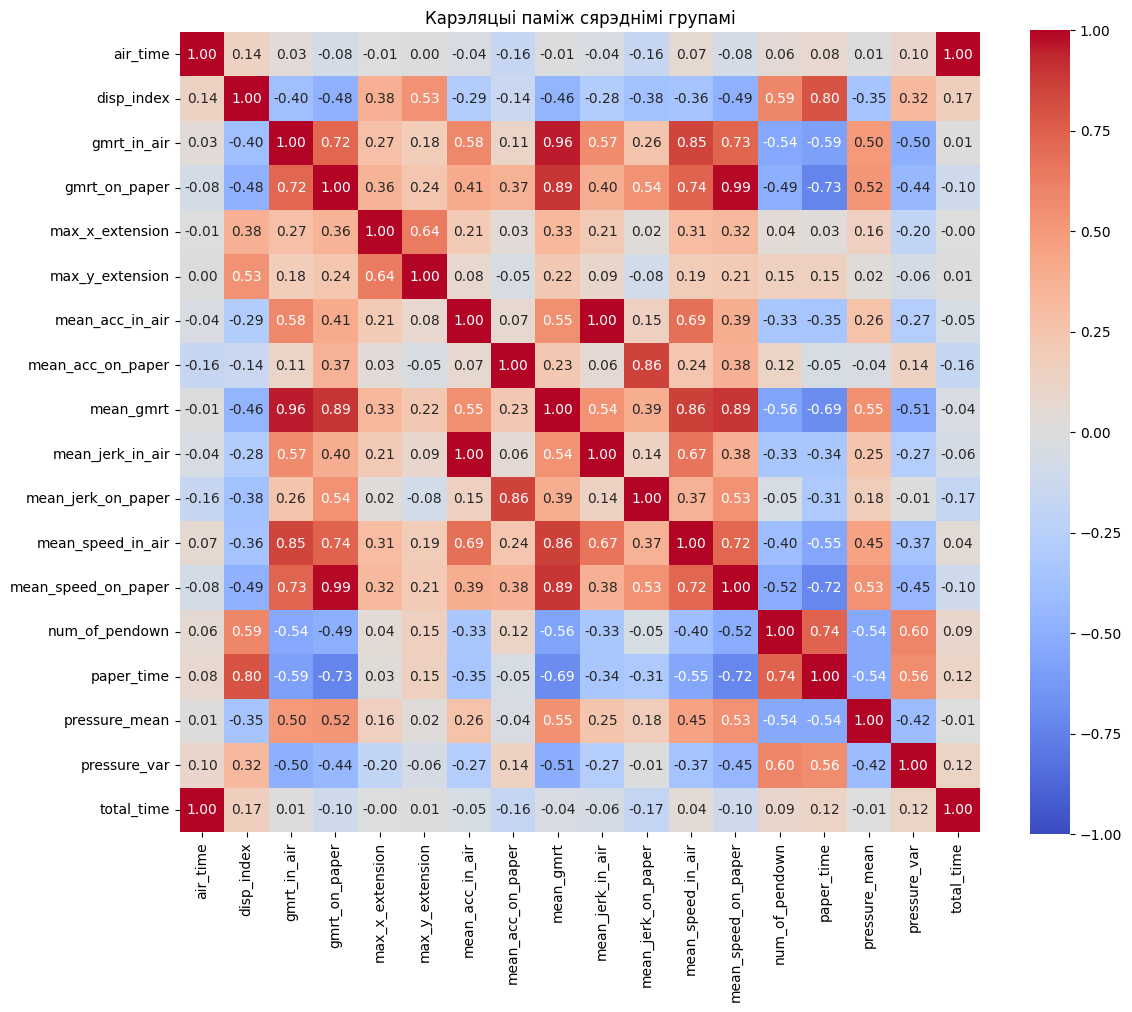

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(corr_means, annot=True, fmt='.2f', cmap='coolwarm', 
            vmin=-1, vmax=1, square=True)
plt.title('Карэляцыі паміж сярэднімі групамі')
plt.tight_layout()
plt.show()

In [23]:
# ============================================================================
# ЧАСТКА 0: НАЛАДА АСЯРОДДЗЯ І ШЛЯХОЎ
# ============================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. СТВАРЭННЕ ДЫРЭКТОРЫІ ДЛЯ ВЫВАДАЎ
output_dir = r'c:\Users\User\Documents\hw6_AD_final_project\outputs'

# Ствараем тэчку, калі яна не існуе
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"✅ Створана дырэкторыя: {output_dir}")
else:
    print(f"✅ Дырэкторыя ўжо існуе: {output_dir}")

# 2. НАЛАДА ШЛЯХОЎ ДЛЯ РОЗНЫХ ТЫПАЎ ФАЙЛАЎ
paths = {
    'figures': os.path.join(output_dir, 'figures'),
    'tables': os.path.join(output_dir, 'tables'),
    'data': os.path.join(output_dir, 'data'),
    'logs': os.path.join(output_dir, 'logs')
}

# Ствараем паддырэкторыі
for name, path in paths.items():
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"✅ Створана: {path}")

# 3. НАЛАДА МАТПЛОТЛІБ ДЛЯ ЗАХАВАННЯ Ў HD ЯКАСЦІ
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

print("\n" + "="*60)
print("НАЛАДА ЗАВЕРШАНА")
print("="*60)
print(f"\n📁 Усе вывады будуць захоўвацца ў:")
print(f"   {output_dir}")
print("\n   Паддырэкторыі:")
for name, path in paths.items():
    print(f"   - {name}: {path}")
print("\n" + "="*60)

✅ Дырэкторыя ўжо існуе: c:\Users\User\Documents\hw6_AD_final_project\outputs
✅ Створана: c:\Users\User\Documents\hw6_AD_final_project\outputs\figures
✅ Створана: c:\Users\User\Documents\hw6_AD_final_project\outputs\tables
✅ Створана: c:\Users\User\Documents\hw6_AD_final_project\outputs\data
✅ Створана: c:\Users\User\Documents\hw6_AD_final_project\outputs\logs

НАЛАДА ЗАВЕРШАНА

📁 Усе вывады будуць захоўвацца ў:
   c:\Users\User\Documents\hw6_AD_final_project\outputs

   Паддырэкторыі:
   - figures: c:\Users\User\Documents\hw6_AD_final_project\outputs\figures
   - tables: c:\Users\User\Documents\hw6_AD_final_project\outputs\tables
   - data: c:\Users\User\Documents\hw6_AD_final_project\outputs\data
   - logs: c:\Users\User\Documents\hw6_AD_final_project\outputs\logs



ПОЎНАЯ МАТРЫЦА КАРЭЛЯЦЫЙ МІЖ ГРУПАМІ
                     air_time  disp_index  gmrt_in_air  gmrt_on_paper  \
air_time                1.000       0.140        0.032         -0.076   
disp_index              0.140       1.000       -0.398         -0.483   
gmrt_in_air             0.032      -0.398        1.000          0.723   
gmrt_on_paper          -0.076      -0.483        0.723          1.000   
max_x_extension        -0.005       0.377        0.274          0.361   
max_y_extension         0.004       0.534        0.183          0.240   
mean_acc_in_air        -0.038      -0.288        0.581          0.409   
mean_acc_on_paper      -0.163      -0.142        0.111          0.375   
mean_gmrt              -0.011      -0.463        0.957          0.893   
mean_jerk_in_air       -0.045      -0.283        0.570          0.397   
mean_jerk_on_paper     -0.161      -0.381        0.256          0.535   
mean_speed_in_air       0.066      -0.363        0.850          0.737   
mean_speed_on_

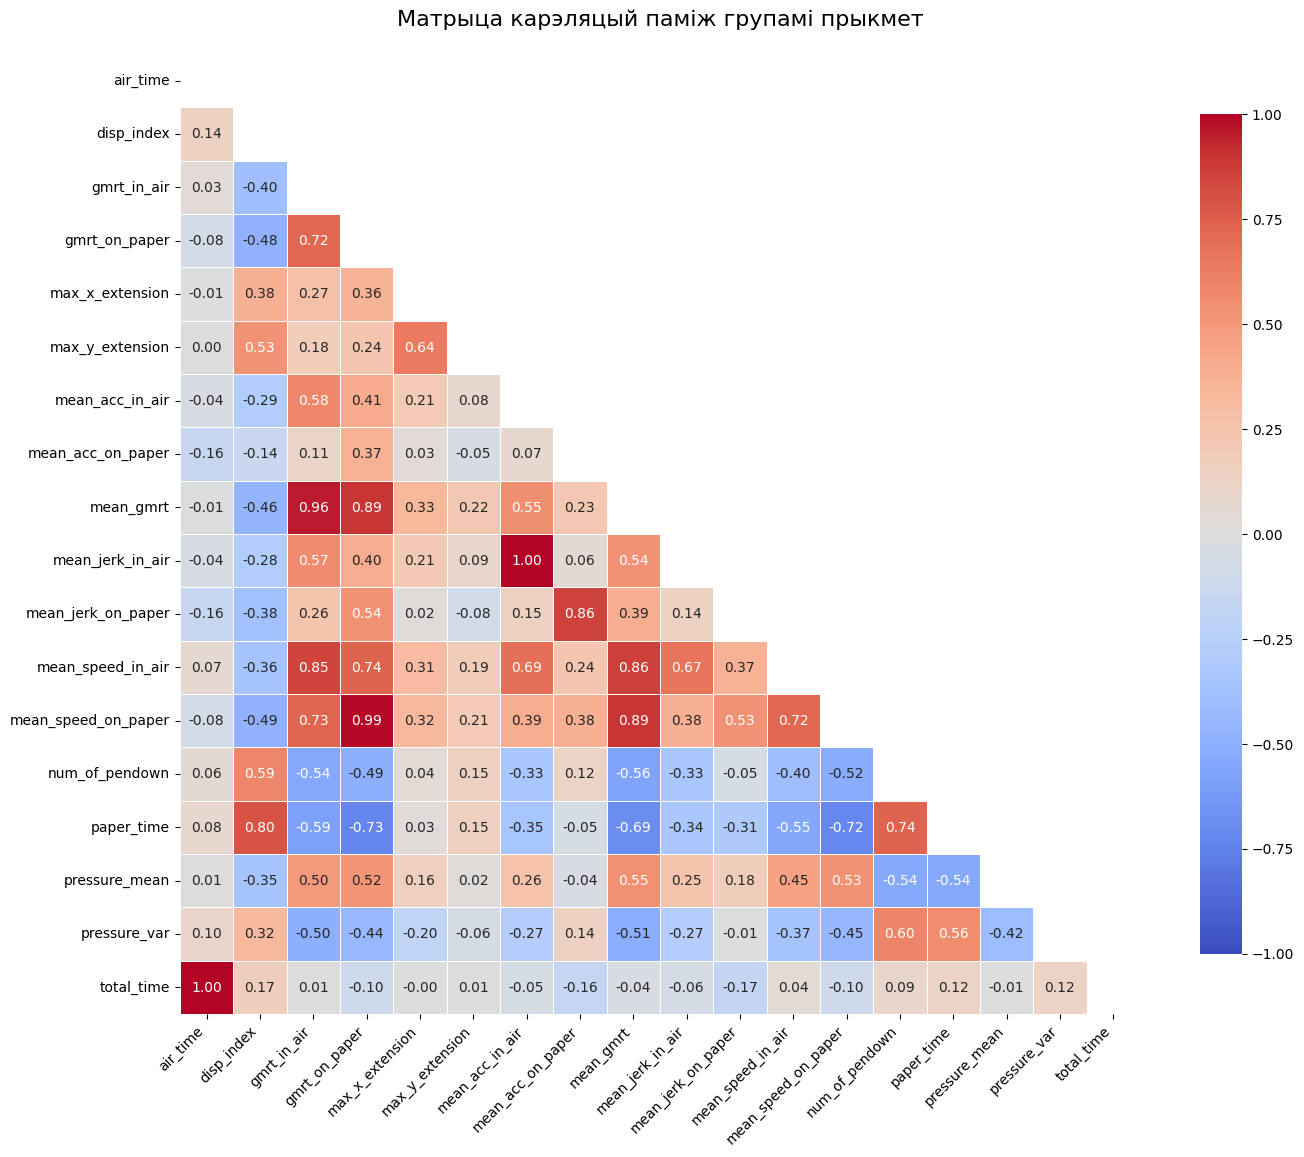


СПІС ГРУП (17 груп)
   1. air_time                  (25 features)
   2. disp_index                (25 features)
   3. gmrt_in_air               (25 features)
   4. gmrt_on_paper             (25 features)
   5. max_x_extension           (25 features)
   6. max_y_extension           (25 features)
   7. mean_acc_in_air           (25 features)
   8. mean_acc_on_paper         (25 features)
   9. mean_gmrt                 (25 features)
  10. mean_jerk_in_air          (25 features)
  11. mean_jerk_on_paper        (25 features)
  12. mean_speed_in_air         (25 features)
  13. mean_speed_on_paper       (25 features)
  14. num_of_pendown            (25 features)
  15. paper_time                (25 features)
  16. pressure_mean             (25 features)
  17. pressure_var              (25 features)
  18. total_time                (25 features)


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# 1. СТВАРЭННЕ СЯРЭДНІХ ПА ГРУПАХ (17 груп без ID)
# ============================================================================
feature_groups_no_id = {k: v for k, v in feature_groups.items() if k != 'ID'}

# Ствараем DataFrame з сярэднімі па кожнай групе
means_df = pd.DataFrame()
for group, cols in feature_groups_no_id.items():
    means_df[group] = df[cols].mean(axis=1)

# ============================================================================
# 2. ПОЎНАЯ МАТРЫЦА КАРЭЛЯЦЫЙ (усе групы)
# ============================================================================
corr_matrix = means_df.corr()

print("="*80)
print("ПОЎНАЯ МАТРЫЦА КАРЭЛЯЦЫЙ МІЖ ГРУПАМІ")
print("="*80)
print(corr_matrix.round(3))

# ============================================================================
# 3. ТОЛЬКІ КАРЭЛЯЦЫІ > 0.6 (без дыяганалі)
# ============================================================================
# Ствараем маску для верхняга трохвугольніка (без дыяганалі)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Збіраем усе карэляцыі ў адзін DataFrame
corr_pairs = corr_matrix.where(mask).stack()
corr_pairs = corr_pairs[corr_pairs != 1.0]  # Выдаляем дыяганаль
corr_pairs = corr_pairs[~np.isnan(corr_pairs)]  # Выдаляем NaN

# Сартуем па ўзрастанні
corr_pairs_sorted = corr_pairs.sort_values(ascending=False)

# Фільтруем > 0.6
high_corr = corr_pairs_sorted[corr_pairs_sorted > 0.6]

print("\n" + "="*80)
print("КАРЭЛЯЦЫІ > 0.6 (адсартаваныя па ўбыванні)")
print("="*80)

if len(high_corr) > 0:
    for (g1, g2), corr in high_corr.items():
        print(f"  {g1:20s} ↔ {g2:20s} : {corr:.3f}")
else:
    print("  Няма карэляцый > 0.6")

# ============================================================================
# 4. ВІЗУАЛІЗАЦЫЯ
# ============================================================================
plt.figure(figsize=(14, 12))

# Ствараем маску для верхняга трохвугольніка
mask_upper = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Будуем heatmap
sns.heatmap(corr_matrix, 
            mask=mask_upper,
            annot=True, 
            fmt='.2f',
            cmap='coolwarm',
            vmin=-1, 
            vmax=1,
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Матрыца карэляцый паміж групамі прыкмет', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# ============================================================================
# 5. ДАДАТКОВА: Спіс груп для даведкі
# ============================================================================
print("\n" + "="*80)
print("СПІС ГРУП (17 груп)")
print("="*80)
for i, (group, cols) in enumerate(sorted(feature_groups_no_id.items()), 1):
    print(f"  {i:2d}. {group:25s} ({len(cols)} features)")

In [19]:
# 1. Загрузка даных
print("="*80)
print("ЗАГРУЗКА ДАТАСЭТУ DARWIN")
print("="*80)

darwin = fetch_ucirepo(id=732)
X = darwin.data.features
y = darwin.data.targets
df = pd.concat([X, y], axis=1)

print(f"✅ Датасэт загружаны: {df.shape[0]} радкоў, {df.shape[1]} калонак")
print(f"   Класы: {y['class'].value_counts().to_dict()}")

# 2. Стварэнне слоўніка катэгорый задач (на аснове дысертацыі)
task_categories = {
    1: 'M', 2: 'G', 3: 'G', 4: 'G', 5: 'G', 
    6: 'C', 7: 'C', 8: 'C', 9: 'C', 10: 'C',
    11: 'C', 12: 'C', 13: 'C', 14: 'M', 15: 'C', 
    16: 'C', 17: 'C', 18: 'M', 19: 'C', 20: 'M', 
    21: 'G', 22: 'C', 23: 'M', 24: 'G', 25: 'C'
}

# Ствараем зваротны слоўнік: катэгорыя -> спіс нумароў задач
category_tasks = {
    'G': [k for k, v in task_categories.items() if v == 'G'],
    'C': [k for k, v in task_categories.items() if v == 'C'],
    'M': [k for k, v in task_categories.items() if v == 'M']
}

print("\n📋 РАЗБІЦЦЁ ЗАДАЧ ПА КАТЭГОРЫЯХ:")
print(f"   Graphic (G): {category_tasks['G']}")
print(f"   Copy (C):    {category_tasks['C']}")
print(f"   Memory (M):  {category_tasks['M']}")

# 3. Вызначэнне 18 базавых тыпаў прыкмет
# Атрымліваем усе назвы калонак, акрамя ID і class
feature_cols = [col for col in df.columns if col not in ['ID', 'class']]

# Групуем па прэфіксах
feature_groups = {}
for col in feature_cols:
    # Выдаляем лічбы ў канцы для вызначэння групы
    prefix = ''.join([c for c in col if not c.isdigit()]).rstrip('_')
    if prefix not in feature_groups:
        feature_groups[prefix] = []
    feature_groups[prefix].append(col)

print(f"\n📁 ВЫЯЎЛЕНА {len(feature_groups)} ТЫПАЎ ПРЫКМЕТ:")
for group, cols in sorted(feature_groups.items()):
    if group != 'ID':  # Прапускаем ID
        print(f"   {group:25s} ({len(cols)} задач)")

print("\n" + "="*80)
print("ЧАСТКА 1 ЗАВЕРШАНА ✅")
print("="*80)


ЗАГРУЗКА ДАТАСЭТУ DARWIN
✅ Датасэт загружаны: 174 радкоў, 452 калонак
   Класы: {'P': 89, 'H': 85}

📋 РАЗБІЦЦЁ ЗАДАЧ ПА КАТЭГОРЫЯХ:
   Graphic (G): [2, 3, 4, 5, 21, 24]
   Copy (C):    [6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 19, 22, 25]
   Memory (M):  [1, 14, 18, 20, 23]

📁 ВЫЯЎЛЕНА 18 ТЫПАЎ ПРЫКМЕТ:
   air_time                  (25 задач)
   disp_index                (25 задач)
   gmrt_in_air               (25 задач)
   gmrt_on_paper             (25 задач)
   max_x_extension           (25 задач)
   max_y_extension           (25 задач)
   mean_acc_in_air           (25 задач)
   mean_acc_on_paper         (25 задач)
   mean_gmrt                 (25 задач)
   mean_jerk_in_air          (25 задач)
   mean_jerk_on_paper        (25 задач)
   mean_speed_in_air         (25 задач)
   mean_speed_on_paper       (25 задач)
   num_of_pendown            (25 задач)
   paper_time                (25 задач)
   pressure_mean             (25 задач)
   pressure_var              (25 задач)
   total_time   

In [20]:
# ============================================================================
# ЧАСТКА 2: СТВАРЭННЕ ПРЫКМЕТ ПА КАТЭГОРЫЯХ ЗАДАЧ
# ============================================================================

print("\n" + "="*80)
print("ЧАСТКА 2: СТВАРЭННЕ ПРЫКМЕТ ПА КАТЭГОРЫЯХ")
print("="*80)

# Ствараем пусты DataFrame для новых прыкмет
features_agg = pd.DataFrame()
features_agg['ID'] = df['ID']
features_agg['class'] = df['class']

# 2.1 Для КОЖНАЙ групы прыкмет (total_time, mean_speed_on_paper, etc.)
for group_name, group_cols in feature_groups.items():
    if group_name == 'ID':
        continue
    
    # 2.2 Для КОЖНАЙ катэгорыі задач (G, C, M)
    for category, task_list in category_tasks.items():
        # Знаходзім калонкі, якія адпавядаюць гэтай катэгорыі
        # Напрыклад: для total_time і катэгорыі G -> total_time2, total_time3, total_time4, total_time5, total_time21, total_time24
        cat_cols = [col for col in group_cols if int(col[-1]) in task_list]
        
        if len(cat_cols) > 0:
            # Сярэдняе па катэгорыі
            features_agg[f'{group_name}_{category}_mean'] = df[cat_cols].mean(axis=1)
            # Стандартнае адхіленне па катэгорыі (стабільнасць)
            features_agg[f'{group_name}_{category}_std'] = df[cat_cols].std(axis=1)
    
    # 2.3 Агульнае сярэдняе па ўсіх задачах (для параўнання)
    features_agg[f'{group_name}_all_mean'] = df[group_cols].mean(axis=1)
    features_agg[f'{group_name}_all_std'] = df[group_cols].std(axis=1)

print(f"✅ Створана {features_agg.shape[1] - 2} новых прыкмет")
print(f"   (без уліку ID і class)")

# Паглядзім некалькі прыкладаў
print("\n📊 ПРЫКЛАДЫ НОВЫХ ПРЫКМЕТ:")
new_features = [col for col in features_agg.columns if col not in ['ID', 'class']]
print(f"   Усяго прыкмет: {len(new_features)}")
print(f"\n   Першыя 10 новых прыкмет:")
for col in new_features[:10]:
    print(f"   - {col}")

# 2.4 Стварэнне суадносін паміж катэгорыямі
print("\n🔄 СТВАРЭННЕ СУАДНОСІН ПАМІЖ КАТЭГОРЫЯМІ:")
ratio_features = []

for group_name in feature_groups.keys():
    if group_name == 'ID':
        continue
        
    # Суадносіны Memory / Graphic
    if f'{group_name}_M_mean' in features_agg.columns and f'{group_name}_G_mean' in features_agg.columns:
        features_agg[f'{group_name}_M_G_ratio'] = features_agg[f'{group_name}_M_mean'] / (features_agg[f'{group_name}_G_mean'] + 1e-10)
        ratio_features.append(f'{group_name}_M_G_ratio')
        
    # Суадносіны Copy / Graphic
    if f'{group_name}_C_mean' in features_agg.columns and f'{group_name}_G_mean' in features_agg.columns:
        features_agg[f'{group_name}_C_G_ratio'] = features_agg[f'{group_name}_C_mean'] / (features_agg[f'{group_name}_G_mean'] + 1e-10)
        ratio_features.append(f'{group_name}_C_G_ratio')
        
    # Суадносіны Memory / Copy
    if f'{group_name}_M_mean' in features_agg.columns and f'{group_name}_C_mean' in features_agg.columns:
        features_agg[f'{group_name}_M_C_ratio'] = features_agg[f'{group_name}_M_mean'] / (features_agg[f'{group_name}_C_mean'] + 1e-10)
        ratio_features.append(f'{group_name}_M_C_ratio')

print(f"✅ Дададзена {len(ratio_features)} суадносін")

print("\n" + "="*80)
print("ЧАСТКА 2 ЗАВЕРШАНА ✅")
print("="*80)


ЧАСТКА 2: СТВАРЭННЕ ПРЫКМЕТ ПА КАТЭГОРЫЯХ
✅ Створана 144 новых прыкмет
   (без уліку ID і class)

📊 ПРЫКЛАДЫ НОВЫХ ПРЫКМЕТ:
   Усяго прыкмет: 144

   Першыя 10 новых прыкмет:
   - air_time_G_mean
   - air_time_G_std
   - air_time_C_mean
   - air_time_C_std
   - air_time_M_mean
   - air_time_M_std
   - air_time_all_mean
   - air_time_all_std
   - disp_index_G_mean
   - disp_index_G_std

🔄 СТВАРЭННЕ СУАДНОСІН ПАМІЖ КАТЭГОРЫЯМІ:
✅ Дададзена 54 суадносін

ЧАСТКА 2 ЗАВЕРШАНА ✅


In [25]:
# ============================================================================
# ЧАСТКА 4: ФІНАЛЬНАЯ ПАДРЫХТОЎКА
# ============================================================================

print("\n" + "="*60)
print("ЧАСТКА 4: ФІНАЛЬНАЯ ПАДРЫХТОЎКА")
print("="*60)

from sklearn.preprocessing import StandardScaler

# Выбар прыкмет
key_groups = ['total_time', 'mean_speed_on_paper', 'mean_acc_on_paper', 
              'pressure_mean', 'num_of_pendown', 'gmrt_on_paper']

final_features = []
for group in key_groups:
    for category in ['G', 'C', 'M']:
        col = f'{group}_{category}_mean'
        if col in features_for_clustering:
            final_features.append(col)
    for ratio in [f'{group}_M_G_ratio', f'{group}_C_G_ratio']:
        if ratio in features_for_clustering:
            final_features.append(ratio)

# Дадаём прасторавыя
for group in ['max_x_extension', 'max_y_extension']:
    for category in ['G', 'C', 'M']:
        col = f'{group}_{category}_mean'
        if col in features_for_clustering:
            final_features.append(col)

final_features = list(set(final_features))

# Стварэнне датасэта
clustering_df = features_agg[final_features + ['ID', 'class']].copy()

# Стандартызацыя
scaler = StandardScaler()
scaled_features = scaler.fit_transform(clustering_df[final_features])
scaled_df = pd.DataFrame(scaled_features, columns=final_features)
scaled_df['ID'] = clustering_df['ID']
scaled_df['class'] = clustering_df['class']

# Захоўваем
scaled_df.to_csv(os.path.join(paths['data'], 'clustering_ready.csv'), index=False)

# Захоўваем спіс прыкмет
with open(os.path.join(paths['logs'], 'final_features.txt'), 'w') as f:
    f.write("ФІНАЛЬНЫ СПІС ПРЫКМЕТ\n")
    f.write("="*50 + "\n")
    for i, col in enumerate(sorted(final_features), 1):
        f.write(f"{i:2d}. {col}\n")

print(f"✅ Фінальны датасэт: {scaled_df.shape[0]} радкоў, {scaled_df.shape[1] - 2} прыкмет")
print(f"✅ Захавана: clustering_ready.csv")
print("\n" + "="*60)
print("ЧАСТКА 4 ЗАВЕРШАНА ✅")
print("="*60)


ЧАСТКА 4: ФІНАЛЬНАЯ ПАДРЫХТОЎКА
✅ Фінальны датасэт: 174 радкоў, 36 прыкмет
✅ Захавана: clustering_ready.csv

ЧАСТКА 4 ЗАВЕРШАНА ✅


In [26]:
# ============================================================================
# ЧАСТКА 5: K-MEANS КЛАСТАРЫЗАЦЫЯ
# ============================================================================

print("\n" + "="*60)
print("ЧАСТКА 5: K-MEANS КЛАСТАРЫЗАЦЫЯ")
print("="*60)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_cluster = scaled_df[final_features].values

# Падбор k
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))

# Графікі
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Колькасць кластараў (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Метад локця')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouettes, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Колькасць кластараў (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Сілуэт')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(paths['figures'], 'kmeans_elbow_silhouette.png'))
plt.close()
print("✅ Захавана: kmeans_elbow_silhouette.png")

# Фінальны K-Means
best_k = k_range[np.argmax(silhouettes)]
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
scaled_df['cluster_kmeans'] = kmeans_final.fit_predict(X_cluster)

# Размеркаванне па кластарах
cluster_counts = scaled_df['cluster_kmeans'].value_counts().sort_index()
cluster_counts.to_csv(os.path.join(paths['tables'], 'kmeans_cluster_counts.csv'))

print(f"🏆 Найлепшае k: {best_k} (Silhouette: {max(silhouettes):.3f})")
print("\n📊 Размеркаванне:")
print(cluster_counts)

# Захоўваем вынікі кластарызацыі
scaled_df.to_csv(os.path.join(paths['data'], 'kmeans_results.csv'), index=False)
print("✅ Захавана: kmeans_results.csv")
print("\n" + "="*60)
print("ЧАСТКА 5 ЗАВЕРШАНА ✅")
print("="*60)


ЧАСТКА 5: K-MEANS КЛАСТАРЫЗАЦЫЯ
✅ Захавана: kmeans_elbow_silhouette.png
🏆 Найлепшае k: 2 (Silhouette: 0.188)

📊 Размеркаванне:
cluster_kmeans
0     44
1    130
Name: count, dtype: int64
✅ Захавана: kmeans_results.csv

ЧАСТКА 5 ЗАВЕРШАНА ✅


In [27]:
# ============================================================================
# ЧАСТКА 6: АНАЛІЗ КЛАСТАРАЎ І ПАРАЎНАННЕ З ДЫЯГНАЗАМ
# ============================================================================

print("\n" + "="*60)
print("ЧАСТКА 6: АНАЛІЗ КЛАСТАРАЎ І ДЫЯГНАЗА")
print("="*60)

# Табліца сумежнасці
cluster_class_crosstab = pd.crosstab(scaled_df['cluster_kmeans'], scaled_df['class'], normalize='index')
cluster_class_counts = pd.crosstab(scaled_df['cluster_kmeans'], scaled_df['class'])

# Захоўваем табліцы
cluster_class_counts.to_csv(os.path.join(paths['tables'], 'cluster_class_counts.csv'))
cluster_class_crosstab.to_csv(os.path.join(paths['tables'], 'cluster_class_proportions.csv'))

print("📊 Табліцы захаваны:")

# Графікі
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cluster_class_counts.plot(kind='bar', ax=axes[0])
axes[0].set_title('Расподзел класаў па кластарах (абсалютныя)')
axes[0].set_xlabel('Кластар')
axes[0].set_ylabel('Колькасць')
axes[0].legend(['H (Здаровыя)', 'P (Хворыя)'])
axes[0].grid(True, alpha=0.3)

cluster_class_crosstab.plot(kind='bar', ax=axes[1])
axes[1].set_title('Расподзел класаў па кластарах (адносныя)')
axes[1].set_xlabel('Кластар')
axes[1].set_ylabel('Доля')
axes[1].legend(['H (Здаровыя)', 'P (Хворыя)'])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(paths['figures'], 'cluster_class_distribution.png'))
plt.close()
print("✅ Захавана: cluster_class_distribution.png")

# Профілі кластараў
cluster_profiles = scaled_df.groupby('cluster_kmeans')[final_features].mean().T
cluster_profiles.to_csv(os.path.join(paths['tables'], 'cluster_profiles.csv'))
print("✅ Захавана: cluster_profiles.csv")

# PCA візуалізацыя
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_cluster)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], 
                     c=scaled_df['cluster_kmeans'], cmap='viridis', 
                     alpha=0.7, s=50)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title('K-Means кластары ў прасторы PCA')
plt.colorbar(scatter, label='Кластар')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(paths['figures'], 'kmeans_pca_visualization.png'))
plt.close()
print("✅ Захавана: kmeans_pca_visualization.png")

print("\n" + "="*60)
print("ЧАСТКА 6 ЗАВЕРШАНА ✅")
print("="*60)

print("\n" + "="*60)
print("🎉 УСЕ ВЫНІКІ ЗАХАВАНЫ!")
print("="*60)
print(f"\n📁 Асноўная тэчка: {output_dir}")
print("\nЗмест:")
for name, path in paths.items():
    print(f"   - {name}: {path}")
print("\n" + "="*60)


ЧАСТКА 6: АНАЛІЗ КЛАСТАРАЎ І ДЫЯГНАЗА
📊 Табліцы захаваны:
✅ Захавана: cluster_class_distribution.png
✅ Захавана: cluster_profiles.csv
✅ Захавана: kmeans_pca_visualization.png

ЧАСТКА 6 ЗАВЕРШАНА ✅

🎉 УСЕ ВЫНІКІ ЗАХАВАНЫ!

📁 Асноўная тэчка: c:\Users\User\Documents\hw6_AD_final_project\outputs

Змест:
   - figures: c:\Users\User\Documents\hw6_AD_final_project\outputs\figures
   - tables: c:\Users\User\Documents\hw6_AD_final_project\outputs\tables
   - data: c:\Users\User\Documents\hw6_AD_final_project\outputs\data
   - logs: c:\Users\User\Documents\hw6_AD_final_project\outputs\logs



In [28]:
# ============================================================================
# ПРАВЕРКА СТРУКТУРЫ ВЫВАДАЎ
# ============================================================================

import os

output_dir = r'c:\Users\User\Documents\hw6_AD_final_project\outputs'

print("="*60)
print("СТРУКТУРА ТЭЧКІ outputs")
print("="*60)

for root, dirs, files in os.walk(output_dir):
    level = root.replace(output_dir, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    sub_indent = ' ' * 2 * (level + 1)
    for file in files:
        print(f"{sub_indent}📄 {file}")

СТРУКТУРА ТЭЧКІ outputs
outputs/
  data/
    📄 clustering_ready.csv
    📄 kmeans_results.csv
  figures/
    📄 cluster_class_distribution.png
    📄 correlation_matrix_full.png
    📄 kmeans_elbow_silhouette.png
    📄 kmeans_pca_visualization.png
  logs/
    📄 final_features.txt
    📄 high_correlations.txt
  tables/
    📄 cluster_class_counts.csv
    📄 cluster_class_proportions.csv
    📄 cluster_profiles.csv
    📄 kmeans_cluster_counts.csv


In [29]:
# ============================================================================
# ДАДАТКОВЫЯ МЕТАДЫ КЛАСТАРЫЗАЦЫІ
# ============================================================================

from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

print("\n" + "="*60)
print("ДАДАТКОВЫЯ МЕТАДЫ КЛАСТАРЫЗАЦЫІ")
print("="*60)

# 1. Іерархічная кластарызацыя
print("\n📊 Іерархічная кластарызацыя...")

# Дэндрограма
plt.figure(figsize=(15, 8))
dendrogram = sch.dendrogram(sch.linkage(X_cluster, method='ward'))
plt.title('Дэндрограма (Ward linkage)')
plt.xlabel('Індэксы назіранняў')
plt.ylabel('Адлегласць')
plt.axhline(y=20, color='r', linestyle='--', label='Парог для 5 кластараў')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(paths['figures'], 'dendrogram.png'))
plt.close()
print("   ✅ Захавана: dendrogram.png")

# Hierarchical з 5 кластарамі
hierarchical = AgglomerativeClustering(n_clusters=5, linkage='ward')
scaled_df['cluster_hier'] = hierarchical.fit_predict(X_cluster)
sil_hier = silhouette_score(X_cluster, scaled_df['cluster_hier'])
print(f"   Silhouette Score (5 кластараў): {sil_hier:.3f}")

# 2. DBSCAN
print("\n📊 DBSCAN...")

# Пошук аптымальных параметраў
eps_values = np.arange(0.5, 3.0, 0.2)
min_samples_values = [3, 5, 7, 10]

best_dbscan_score = -1
best_params = None

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_cluster)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        if n_clusters >= 2 and n_noise < len(X_cluster) * 0.3:
            try:
                score = silhouette_score(X_cluster[labels != -1], labels[labels != -1])
                if score > best_dbscan_score:
                    best_dbscan_score = score
                    best_params = (eps, min_samples)
            except:
                pass

if best_params:
    dbscan = DBSCAN(eps=best_params[0], min_samples=best_params[1])
    scaled_df['cluster_dbscan'] = dbscan.fit_predict(X_cluster)
    n_clusters = len(set(scaled_df['cluster_dbscan'])) - (1 if -1 in scaled_df['cluster_dbscan'] else 0)
    n_noise = list(scaled_df['cluster_dbscan']).count(-1)
    
    print(f"   Найлепшыя параметры: eps={best_params[0]}, min_samples={best_params[1]}")
    print(f"   Колькасць кластараў: {n_clusters}")
    print(f"   Шум (метка -1): {n_noise} назіранняў ({n_noise/len(X_cluster)*100:.1f}%)")
    print(f"   Silhouette Score: {best_dbscan_score:.3f}")
else:
    print("   Не атрымалася знайсці добрыя параметры для DBSCAN")

# Захоўваем вынікі
scaled_df.to_csv(os.path.join(paths['data'], 'all_clustering_results.csv'), index=False)
print("\n✅ Усе вынікі кластарызацыі захаваны: all_clustering_results.csv")
print("\n" + "="*60)


ДАДАТКОВЫЯ МЕТАДЫ КЛАСТАРЫЗАЦЫІ

📊 Іерархічная кластарызацыя...
   ✅ Захавана: dendrogram.png
   Silhouette Score (5 кластараў): 0.090

📊 DBSCAN...
   Не атрымалася знайсці добрыя параметры для DBSCAN

✅ Усе вынікі кластарызацыі захаваны: all_clustering_results.csv



Нізкі (магчыма?)сілуэт. Альцгеймер уплывае на почырк паступова? Адказ неўрасеткі: дадзеныя адпавядаюць медыцынскай рэальнасці.



In [3]:
# ============================================================================
# ПОЎНЫ КОД ДЛЯ ПОШУКУ АНАМАЛІЙ (з загрузкай даных)
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA

# 1. ШЛЯХ ДА ТЭЧКІ З ВЫВАДАМІ
output_dir = r'c:\Users\User\Documents\hw6_AD_final_project\outputs'

# 2. ЗАГРУЗКА ДАНЫХ
print("="*60)
print("ЗАГРУЗКА ДАНЫХ")
print("="*60)

# Спачатку спрабуем загрузіць з kmeans_results.csv
try:
    scaled_df = pd.read_csv(os.path.join(output_dir, 'data', 'kmeans_results.csv'))
    print(f"✅ Загружаны даныя з kmeans_results.csv: {scaled_df.shape}")
except:
    # Калі няма, спрабуем з clustering_ready.csv
    scaled_df = pd.read_csv(os.path.join(output_dir, 'data', 'clustering_ready.csv'))
    print(f"✅ Загружаны даныя з clustering_ready.csv: {scaled_df.shape}")

# 3. ВЫЗНАЧЭННЕ СПІСУ ПРЫКМЕТ
print("\n" + "="*60)
print("ВЫЗНАЧЭННЕ ПРЫКМЕТ")
print("="*60)

# Спосаб 1: спрабуем загрузіць з лаг-файла
final_features = []
try:
    with open(os.path.join(output_dir, 'logs', 'final_features.txt'), 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines:
            if line.strip() and line.strip()[0].isdigit():
                feature = line.strip().split('. ', 1)[-1]
                final_features.append(feature)
    print(f"✅ Загружана {len(final_features)} прыкмет з final_features.txt")
except:
    # Спосаб 2: вызначаем аўтаматычна
    exclude_cols = ['ID', 'class', 'cluster_kmeans', 'cluster_hier', 
                   'cluster_dbscan', 'anomaly_if', 'anomaly_lof']
    final_features = [col for col in scaled_df.columns if col not in exclude_cols]
    print(f"✅ Вызначана {len(final_features)} прыкмет аўтаматычна")

if len(final_features) == 0:
    # Спосаб 3: бярэм усе лічбавыя калонкі
    final_features = scaled_df.select_dtypes(include=[np.number]).columns.tolist()
    final_features = [col for col in final_features if col not in ['ID', 'cluster_kmeans', 'cluster_hier', 'cluster_dbscan']]
    print(f"✅ Узята {len(final_features)} лічбавых прыкмет")

print(f"   Першыя 5 прыкмет: {final_features[:5]}")

# 4. ПАДРЫХТОЎКА ДАНЫХ ДЛЯ КЛАСТАРЫЗАЦЫІ
print("\n" + "="*60)
print("ПАДРЫХТОЎКА ДАНЫХ")
print("="*60)

X_cluster = scaled_df[final_features].values
print(f"   Матрыца прыкмет: {X_cluster.shape}")

# 5. ISOLATION FOREST
print("\n" + "="*60)
print("ISOLATION FOREST")
print("="*60)

iso_forest = IsolationForest(contamination=0.1, random_state=42)
anomaly_labels_if = iso_forest.fit_predict(X_cluster)
n_anomalies_if = (anomaly_labels_if == -1).sum()
scaled_df['anomaly_if'] = anomaly_labels_if

print(f"   Выяўлена анамалій: {n_anomalies_if} ({n_anomalies_if/len(X_cluster)*100:.1f}%)")

# 6. LOCAL OUTLIER FACTOR
print("\n" + "="*60)
print("LOCAL OUTLIER FACTOR")
print("="*60)

lof = LocalOutlierFactor(contamination=0.1, novelty=False)
anomaly_labels_lof = lof.fit_predict(X_cluster)
n_anomalies_lof = (anomaly_labels_lof == -1).sum()
scaled_df['anomaly_lof'] = anomaly_labels_lof

print(f"   Выяўлена анамалій: {n_anomalies_lof} ({n_anomalies_lof/len(X_cluster)*100:.1f}%)")

# 7. ПАРАЎНАННЕ МЕТАДАЎ
print("\n" + "="*60)
print("ПАРАЎНАННЕ МЕТАДАЎ")
print("="*60)

overlap = ((scaled_df['anomaly_if'] == -1) & (scaled_df['anomaly_lof'] == -1)).sum()
print(f"   Абедзвюма метадамі выяўлена анамалій: {overlap}")
print(f"   Толькі Isolation Forest: {n_anomalies_if - overlap}")
print(f"   Толькі LOF: {n_anomalies_lof - overlap}")

# 8. АНАЛІЗ АНАМАЛІЙ У КАНТЭКСЦЕ ДЫЯГНАЗУ
print("\n" + "="*60)
print("АНАЛІЗ АНАМАЛІЙ У КАНТЭКСЦЕ ДЫЯГНАЗУ")
print("="*60)

if n_anomalies_if > 0:
    anomalies_if = scaled_df[scaled_df['anomaly_if'] == -1]
    p_in_anomalies_if = (anomalies_if['class'] == 'P').sum()
    print(f"\n   Isolation Forest:")
    print(f"      Колькасць анамалій: {n_anomalies_if}")
    print(f"      Хворых (P): {p_in_anomalies_if} ({p_in_anomalies_if/n_anomalies_if*100:.1f}%)")
    print(f"      Здаровых (H): {n_anomalies_if - p_in_anomalies_if}")

if n_anomalies_lof > 0:
    anomalies_lof = scaled_df[scaled_df['anomaly_lof'] == -1]
    p_in_anomalies_lof = (anomalies_lof['class'] == 'P').sum()
    print(f"\n   LOF:")
    print(f"      Колькасць анамалій: {n_anomalies_lof}")
    print(f"      Хворых (P): {p_in_anomalies_lof} ({p_in_anomalies_lof/n_anomalies_lof*100:.1f}%)")
    print(f"      Здаровых (H): {n_anomalies_lof - p_in_anomalies_lof}")

# 9. ЗАХАВАННЕ ВЫНІКАЎ
print("\n" + "="*60)
print("ЗАХАВАННЕ ВЫНІКАЎ")
print("="*60)

scaled_df.to_csv(os.path.join(output_dir, 'data', 'anomaly_detection_results.csv'), index=False)
print(f"   ✅ Захавана: {os.path.join(output_dir, 'data', 'anomaly_detection_results.csv')}")

# 10. ВІЗУАЛІЗАЦЫЯ
print("\n" + "="*60)
print("ВІЗУАЛІЗАЦЫЯ")
print("="*60)

# PCA для візуалізацыі
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_cluster)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Isolation Forest
if n_anomalies_if > 0:
    axes[0].scatter(pca_result[scaled_df['anomaly_if'] == 1, 0], 
                   pca_result[scaled_df['anomaly_if'] == 1, 1],
                   c='blue', label='Звычайныя', alpha=0.6)
    axes[0].scatter(pca_result[scaled_df['anomaly_if'] == -1, 0], 
                   pca_result[scaled_df['anomaly_if'] == -1, 1],
                   c='red', label='Анамаліі', alpha=0.8, s=80)
else:
    axes[0].scatter(pca_result[:, 0], pca_result[:, 1], c='blue', alpha=0.6)
axes[0].set_title(f'Isolation Forest ({n_anomalies_if} анамалій)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# LOF
if n_anomalies_lof > 0:
    axes[1].scatter(pca_result[scaled_df['anomaly_lof'] == 1, 0], 
                   pca_result[scaled_df['anomaly_lof'] == 1, 1],
                   c='blue', label='Звычайныя', alpha=0.6)
    axes[1].scatter(pca_result[scaled_df['anomaly_lof'] == -1, 0], 
                   pca_result[scaled_df['anomaly_lof'] == -1, 1],
                   c='red', label='Анамаліі', alpha=0.8, s=80)
else:
    axes[1].scatter(pca_result[:, 0], pca_result[:, 1], c='blue', alpha=0.6)
axes[1].set_title(f'LOF ({n_anomalies_lof} анамалій)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figures', 'anomaly_detection_visualization.png'))
plt.close()
print(f"   ✅ Захавана: {os.path.join(output_dir, 'figures', 'anomaly_detection_visualization.png')}")

# 11. КАРОТКАЯ СПРАВАЗДАЧА
print("\n" + "="*60)
print("КАРОТКАЯ СПРАВАЗДАЧА ПА АНАМАЛІЯХ")
print("="*60)

print(f"""
Анамаліі былі выяўлены наступнымі метадамі:

1. Isolation Forest:
   - Выяўлена анамалій: {n_anomalies_if} ({n_anomalies_if/len(X_cluster)*100:.1f}%)
   - Хворых сярод анамалій: {p_in_anomalies_if if n_anomalies_if > 0 else 0} ({p_in_anomalies_if/n_anomalies_if*100 if n_anomalies_if > 0 else 0:.1f}%)

2. LOF (Local Outlier Factor):
   - Выяўлена анамалій: {n_anomalies_lof} ({n_anomalies_lof/len(X_cluster)*100:.1f}%)
   - Хворых сярод анамалій: {p_in_anomalies_lof if n_anomalies_lof > 0 else 0} ({p_in_anomalies_lof/n_anomalies_lof*100 if n_anomalies_lof > 0 else 0:.1f}%)

3. Супадзенне паміж метадамі: {overlap}
   - Толькі Isolation Forest: {n_anomalies_if - overlap if n_anomalies_if > 0 else 0}
   - Толькі LOF: {n_anomalies_lof - overlap if n_anomalies_lof > 0 else 0}
""")

print("="*60)
print("АНАЛІЗ АНАМАЛІЙ ЗАВЕРШАНЫ ✅")
print("="*60)

ЗАГРУЗКА ДАНЫХ
✅ Загружаны даныя з kmeans_results.csv: (174, 39)

ВЫЗНАЧЭННЕ ПРЫКМЕТ
✅ Вызначана 36 прыкмет аўтаматычна
   Першыя 5 прыкмет: ['mean_speed_on_paper_C_G_ratio', 'max_x_extension_G_mean', 'num_of_pendown_M_G_ratio', 'mean_acc_on_paper_M_mean', 'mean_acc_on_paper_C_mean']

ПАДРЫХТОЎКА ДАНЫХ
   Матрыца прыкмет: (174, 36)

ISOLATION FOREST
   Выяўлена анамалій: 18 (10.3%)

LOCAL OUTLIER FACTOR
   Выяўлена анамалій: 18 (10.3%)

ПАРАЎНАННЕ МЕТАДАЎ
   Абедзвюма метадамі выяўлена анамалій: 9
   Толькі Isolation Forest: 9
   Толькі LOF: 9

АНАЛІЗ АНАМАЛІЙ У КАНТЭКСЦЕ ДЫЯГНАЗУ

   Isolation Forest:
      Колькасць анамалій: 18
      Хворых (P): 13 (72.2%)
      Здаровых (H): 5

   LOF:
      Колькасць анамалій: 18
      Хворых (P): 8 (44.4%)
      Здаровых (H): 10

ЗАХАВАННЕ ВЫНІКАЎ
   ✅ Захавана: c:\Users\User\Documents\hw6_AD_final_project\outputs\data\anomaly_detection_results.csv

ВІЗУАЛІЗАЦЫЯ
   ✅ Захавана: c:\Users\User\Documents\hw6_AD_final_project\outputs\figures\anomaly_d

Ці супадаюць анамаліі з нізкім сілуэтам К-мeans. p value<0.05

In [4]:
# ============================================================================
# ПРАВЕРКА: АНАМАЛІІ VS НІЗКІ СІЛУЭТ
# ============================================================================

from sklearn.metrics import silhouette_samples

print("\n" + "="*60)
print("ПРАВЕРКА: АНАМАЛІІ VS НІЗКІ СІЛУЭТ")
print("="*60)

# Разлічваем сілуэт для кожнага аб'екта
silhouette_vals = silhouette_samples(X_cluster, scaled_df['cluster_kmeans'])

# Дадаем у датасэт
scaled_df['silhouette'] = silhouette_vals

# Анамаліі (якія выяўлены хоць адным метадам)
scaled_df['is_anomaly'] = ((scaled_df['anomaly_if'] == -1) | (scaled_df['anomaly_lof'] == -1)).astype(int)

# Параўнанне сілуэта для анамалій і звычайных
anomaly_sil = scaled_df[scaled_df['is_anomaly'] == 1]['silhouette']
normal_sil = scaled_df[scaled_df['is_anomaly'] == 0]['silhouette']

print(f"Сярэдні сілуэт для анамалій: {anomaly_sil.mean():.3f}")
print(f"Сярэдні сілуэт для звычайных: {normal_sil.mean():.3f}")

# Праверка з дапамогай t-тэсту
from scipy import stats
t_stat, p_value = stats.ttest_ind(anomaly_sil, normal_sil)
print(f"T-статыстыка: {t_stat:.3f}, p-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Розніца статыстычна значная! Анамаліі маюць ніжэйшы сілуэт.")
else:
    print("⚠️ Розніца не статыстычна значная.")


ПРАВЕРКА: АНАМАЛІІ VS НІЗКІ СІЛУЭТ
Сярэдні сілуэт для анамалій: 0.158
Сярэдні сілуэт для звычайных: 0.193
T-статыстыка: -1.857, p-value: 0.0651
⚠️ Розніца не статыстычна значная.


In [5]:
# ============================================================================
# ПРОФІЛЬ АНАМАЛІЙ
# ============================================================================

print("\n" + "="*60)
print("ПРОФІЛЬ АНАМАЛІЙ")
print("="*60)

# Сярэднія для анамалій і звычайных
anomaly_profile = scaled_df[scaled_df['is_anomaly'] == 1][final_features].mean()
normal_profile = scaled_df[scaled_df['is_anomaly'] == 0][final_features].mean()

# Розніца
profile_diff = anomaly_profile - normal_profile

# Тап-5 адрозненняў
print("🔝 5 прыкмет, па якіх анамаліі найбольш адрозніваюцца:")
top_diff = profile_diff.abs().sort_values(ascending=False).head(5)
for feature, diff in top_diff.items():
    direction = "вышэй" if diff > 0 else "ніжэй"
    print(f"   {feature}: {direction} на {abs(diff):.3f}")

# Захоўваем профіль
profile_df = pd.DataFrame({
    'feature': final_features,
    'anomaly_mean': anomaly_profile,
    'normal_mean': normal_profile,
    'difference': profile_diff
})
profile_df.to_csv(os.path.join(output_dir, 'tables', 'anomaly_profile.csv'), index=False)
print("\n✅ Профіль захаваны: anomaly_profile.csv")


ПРОФІЛЬ АНАМАЛІЙ
🔝 5 прыкмет, па якіх анамаліі найбольш адрозніваюцца:
   total_time_C_G_ratio: вышэй на 0.873
   total_time_M_mean: вышэй на 0.852
   num_of_pendown_C_mean: вышэй на 0.828
   total_time_G_mean: вышэй на 0.802
   num_of_pendown_G_mean: вышэй на 0.782

✅ Профіль захаваны: anomaly_profile.csv


Які дыягназ?

In [6]:
# ============================================================================
# АНАМАЛІІ І ДЫЯГНАЗ
# ============================================================================

print("\n" + "="*60)
print("АНАМАЛІІ І ДЫЯГНАЗ")
print("="*60)

# Як анамаліі размеркаваны па класах?
anomaly_class_counts = scaled_df[scaled_df['is_anomaly'] == 1]['class'].value_counts()
normal_class_counts = scaled_df[scaled_df['is_anomaly'] == 0]['class'].value_counts()

print("Класы сярод анамалій:")
print(anomaly_class_counts)

print("\nКласы сярод звычайных:")
print(normal_class_counts)

# Табліца сумежнасці
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(scaled_df['class'] == 'P', scaled_df['is_anomaly'])

print("\n📊 Матрыца сумежнасці (P = хворыя):")
print(f"   Анамаліі сярод хворых: {cm[1][1]}")
print(f"   Анамаліі сярод здаровых: {cm[0][1]}")
print(f"   Звычайныя сярод хворых: {cm[1][0]}")
print(f"   Звычайныя сярод здаровых: {cm[0][0]}")

# Доля хворых сярод анамалій
if len(anomaly_class_counts) > 0:
    pct_p_in_anomalies = anomaly_class_counts.get('P', 0) / anomaly_class_counts.sum() * 100
    print(f"\nДоля хворых (P) сярод анамалій: {pct_p_in_anomalies:.1f}%")
else:
    print("\n⚠️ Няма анамалій для аналізу")


АНАМАЛІІ І ДЫЯГНАЗ
Класы сярод анамалій:
class
P    16
H    11
Name: count, dtype: int64

Класы сярод звычайных:
class
H    74
P    73
Name: count, dtype: int64

📊 Матрыца сумежнасці (P = хворыя):
   Анамаліі сярод хворых: 16
   Анамаліі сярод здаровых: 11
   Звычайныя сярод хворых: 73
   Звычайныя сярод здаровых: 74

Доля хворых (P) сярод анамалій: 59.3%


In [7]:
# ============================================================================
# ВІЗУАЛІЗАЦЫЯ ПРОФІЛЮ АНАМАЛІЙ (ПУНКТ Б)
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Шлях да тэчкі з вывадамі
output_dir = r'c:\Users\User\Documents\hw6_AD_final_project\outputs'

# 1. ЗАГРУЗКА ДАНЫХ (калі яшчэ не загружаны)
try:
    scaled_df = pd.read_csv(os.path.join(output_dir, 'data', 'anomaly_detection_results.csv'))
    print(f"✅ Загружаны даныя з anomaly_detection_results.csv: {scaled_df.shape}")
except:
    scaled_df = pd.read_csv(os.path.join(output_dir, 'data', 'kmeans_results.csv'))
    print(f"✅ Загружаны даныя з kmeans_results.csv: {scaled_df.shape}")

# 2. ВЫЗНАЧЭННЕ СПІСУ ПРЫКМЕТ
exclude_cols = ['ID', 'class', 'cluster_kmeans', 'cluster_hier', 
               'cluster_dbscan', 'anomaly_if', 'anomaly_lof', 
               'is_anomaly', 'silhouette']
final_features = [col for col in scaled_df.columns if col not in exclude_cols]

if len(final_features) == 0:
    # Калі спіс пусты, бярэм усе лічбавыя
    final_features = scaled_df.select_dtypes(include=[np.number]).columns.tolist()
    final_features = [col for col in final_features if col not in ['ID', 'cluster_kmeans', 'cluster_hier', 'cluster_dbscan', 'anomaly_if', 'anomaly_lof']]

print(f"🔢 Колькасць прыкмет для аналізу: {len(final_features)}")

# Пераканаемся, што is_anomaly існуе
if 'is_anomaly' not in scaled_df.columns:
    scaled_df['is_anomaly'] = ((scaled_df['anomaly_if'] == -1) | (scaled_df['anomaly_lof'] == -1)).astype(int)

# 3. РАЗЛІК СЯРЭДНІХ ДЛЯ АНАМАЛІЙ І ЗВЫЧАЙНЫХ
print("\n" + "="*60)
print("РАЗЛІК ПРОФІЛЯЎ")
print("="*60)

anomaly_profile = scaled_df[scaled_df['is_anomaly'] == 1][final_features].mean()
normal_profile = scaled_df[scaled_df['is_anomaly'] == 0][final_features].mean()
profile_diff = anomaly_profile - normal_profile

print(f"✅ Профіль анамалій (n={len(scaled_df[scaled_df['is_anomaly'] == 1])})")
print(f"✅ Профіль звычайных (n={len(scaled_df[scaled_df['is_anomaly'] == 0])})")

# 4. ГРУПОЎКА ПРЫКМЕТ ДЛЯ ЛЕПШАЙ ІНТЭРПРЭТАЦЫІ
# (на аснове структуры DARWIN)
feature_groups_for_vis = {
    'Час (Time)': ['total_time', 'air_time', 'paper_time'],
    'Хуткасць (Speed)': ['mean_speed_on_paper', 'mean_speed_in_air'],
    'Паскарэнне (Acceleration)': ['mean_acc_on_paper', 'mean_acc_in_air'],
    'Рывок (Jerk)': ['mean_jerk_on_paper', 'mean_jerk_in_air'],
    'Трэмар (GMRT)': ['gmrt_on_paper', 'gmrt_in_air', 'mean_gmrt'],
    'Ціск (Pressure)': ['pressure_mean', 'pressure_var'],
    'Каардынацыя': ['num_of_pendown', 'disp_index'],
    'Прастора': ['max_x_extension', 'max_y_extension']
}

# Знаходзім прыкметы, якія ёсць у нашым спісе
matched_groups = {}
for group_name, patterns in feature_groups_for_vis.items():
    matched = []
    for pattern in patterns:
        # Шукаем прыкметы, якія ўтрымліваюць гэты шаблон
        for feat in final_features:
            if pattern in feat:
                matched.append(feat)
    if matched:
        matched_groups[group_name] = matched

print(f"\n📊 Групы прыкмет для візуалізацыі:")
for group, feats in matched_groups.items():
    print(f"   {group}: {len(feats)} прыкмет")

# 5. ВІЗУАЛІЗАЦЫЯ 1: ПАРАЛЕЛЬНЫЯ КААРДЫНАТЫ
print("\n" + "="*60)
print("СТВАРЭННЕ ВІЗУАЛІЗАЦЫЙ")
print("="*60)

# Выбіраем топ-10 прыкмет па розніцы
top_features = profile_diff.abs().sort_values(ascending=False).head(10).index.tolist()

plt.figure(figsize=(14, 8))

# Падрыхтоўка даных для паралельных каардынат
plot_df = pd.DataFrame({
    'anomaly': anomaly_profile[top_features],
    'normal': normal_profile[top_features]
}).T

# Нармалізацыя для адлюстравання на адным графіку
from sklearn.preprocessing import MinMaxScaler
scaler_plot = MinMaxScaler()
plot_df_scaled = pd.DataFrame(scaler_plot.fit_transform(plot_df.T).T, 
                              index=plot_df.index, 
                              columns=plot_df.columns)

# Малюнак
for idx, row in plot_df_scaled.iterrows():
    if idx == 'anomaly':
        plt.plot(range(len(top_features)), row, 'o-', color='red', 
                linewidth=2.5, markersize=8, label='Анамаліі')
    else:
        plt.plot(range(len(top_features)), row, 'o-', color='blue', 
                linewidth=2.5, markersize=8, label='Звычайныя')

plt.xticks(range(len(top_features)), top_features, rotation=45, ha='right', fontsize=10)
plt.xlabel('Прыкметы', fontsize=12)
plt.ylabel('Нармалізаванае значэнне', fontsize=12)
plt.title('Паралельныя каардынаты: Профіль анамалій vs Звычайных', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figures', 'anomaly_parallel_coordinates.png'), dpi=300)
plt.close()
print("   ✅ Захавана: anomaly_parallel_coordinates.png")

# 6. ВІЗУАЛІЗАЦЫЯ 2: ГІСТАГРАМЫ РОЗНІЦ
plt.figure(figsize=(14, 8))

# Сартуем па розніцы
sorted_diff = profile_diff.sort_values(ascending=False)
top_positive = sorted_diff.head(10)  # дзе анамаліі вышэй
top_negative = sorted_diff.tail(10)  # дзе анамаліі ніжэй

# Аб'ядноўваем для адлюстравання
top_combined = pd.concat([top_positive, top_negative])

colors = ['red' if x > 0 else 'blue' for x in top_combined.values]
plt.barh(range(len(top_combined)), top_combined.values, color=colors, alpha=0.7)
plt.yticks(range(len(top_combined)), top_combined.index, fontsize=10)
plt.xlabel('Розніца (анамаліі - звычайныя)', fontsize=12)
plt.title('Топ прыкмет, па якіх анамаліі адрозніваюцца ад звычайных', fontsize=14)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figures', 'anomaly_feature_differences.png'), dpi=300)
plt.close()
print("   ✅ Захавана: anomaly_feature_differences.png")

# 7. ВІЗУАЛІЗАЦЫЯ 3: ЦЯПЛАВЫЯ КАРТЫ ПРОФІЛЯЎ (HEATMAP)
plt.figure(figsize=(16, 8))

# Ствараем датафрэйм для цяплавой карты
# Бяром асноўныя групы прыкмет
selected_features = []
for group, feats in matched_groups.items():
    # Бяром па 2-3 прыкметы з кожнай групы
    selected_features.extend(feats[:3])

# Пераканаемся, што яны ёсць у нашых даных
selected_features = [f for f in selected_features if f in final_features]

# Нармалізуем для параўнання
profile_df_heat = pd.DataFrame({
    'Анамаліі': anomaly_profile[selected_features],
    'Звычайныя': normal_profile[selected_features]
}).T

# Нармалізацыя па калонках
from sklearn.preprocessing import StandardScaler
scaler_heat = StandardScaler()
profile_scaled = pd.DataFrame(scaler_heat.fit_transform(profile_df_heat.T).T,
                             index=profile_df_heat.index,
                             columns=profile_df_heat.columns)

sns.heatmap(profile_scaled, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, cbar_kws={'label': 'Нармалізаванае значэнне'})
plt.title('Профіль прыкмет: Анамаліі vs Звычайныя', fontsize=14)
plt.xlabel('Прыкметы', fontsize=12)
plt.ylabel('Група', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figures', 'anomaly_heatmap.png'), dpi=300)
plt.close()
print("   ✅ Захавана: anomaly_heatmap.png")

# 8. ВІЗУАЛІЗАЦЫЯ 4: РАДАР-ЧАРТ ДЛЯ КЛЮЧАВЫХ ГРУП
print("\n" + "="*60)
print("СТВАРЭННЕ РАДАР-ЧАРТАЎ")
print("="*60)

# Бяром сярэднія па групах
group_means_anomaly = {}
group_means_normal = {}

for group_name, feats in matched_groups.items():
    # Бяром толькі тыя прыкметы, якія ёсць у даных
    available = [f for f in feats if f in final_features]
    if available:
        group_means_anomaly[group_name] = anomaly_profile[available].mean()
        group_means_normal[group_name] = normal_profile[available].mean()

# Ствараем радар-чарт
categories = list(group_means_anomaly.keys())
values_anomaly = [group_means_anomaly[cat] for cat in categories]
values_normal = [group_means_normal[cat] for cat in categories]

# Нармалізуем для радара
from sklearn.preprocessing import MinMaxScaler
scaler_radar = MinMaxScaler()
radar_data = np.array([values_anomaly, values_normal]).reshape(2, -1)
radar_data_scaled = scaler_radar.fit_transform(radar_data.T).T

# Малюем
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]  # Замыкаем кола

# Анамаліі
values_anomaly_plot = radar_data_scaled[0].tolist()
values_anomaly_plot += values_anomaly_plot[:1]
ax.plot(angles, values_anomaly_plot, 'o-', linewidth=2, label='Анамаліі', color='red')
ax.fill(angles, values_anomaly_plot, alpha=0.25, color='red')

# Звычайныя
values_normal_plot = radar_data_scaled[1].tolist()
values_normal_plot += values_normal_plot[:1]
ax.plot(angles, values_normal_plot, 'o-', linewidth=2, label='Звычайныя', color='blue')
ax.fill(angles, values_normal_plot, alpha=0.25, color='blue')

# Налады
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Радар-чарт: Профіль анамалій vs Звычайных', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figures', 'anomaly_radar_chart.png'), dpi=300)
plt.close()
print("   ✅ Захавана: anomaly_radar_chart.png")

# 9. ЗАХАВАННЕ ТАБЛІЦЫ З ПРОФІЛЕМ
print("\n" + "="*60)
print("ЗАХАВАННЕ ТАБЛІЦ")
print("="*60)

profile_table = pd.DataFrame({
    'Прыкмета': final_features,
    'Сярэдняе (анамаліі)': anomaly_profile[final_features].values,
    'Сярэдняе (звычайныя)': normal_profile[final_features].values,
    'Розніца': profile_diff[final_features].values,
    'Адн. розніца (%)': (profile_diff[final_features].values / (normal_profile[final_features].values + 1e-10) * 100)
})
profile_table = profile_table.sort_values('Розніца', ascending=False)
profile_table.to_csv(os.path.join(output_dir, 'tables', 'anomaly_profile_full.csv'), index=False)
print(f"   ✅ Захавана: anomaly_profile_full.csv")

# 10. КАРОТКАЯ СПРАВАЗДАЧА
print("\n" + "="*60)
print("КАРОТКАЯ СПРАВАЗДАЧА")
print("="*60)

# Топ-5 адрозненняў
print("\n🔝 ТОП-5 ПРЫКМЕТ, ДЗЕ АНАМАЛІІ ВЫШЭЙ:")
top5_pos = profile_diff.sort_values(ascending=False).head(5)
for feat, val in top5_pos.items():
    print(f"   {feat}: {val:.3f}")

print("\n🔝 ТОП-5 ПРЫКМЕТ, ДЗЕ АНАМАЛІІ НІЖЭЙ:")
top5_neg = profile_diff.sort_values(ascending=True).head(5)
for feat, val in top5_neg.items():
    print(f"   {feat}: {val:.3f}")

print("\n" + "="*60)
print("🎉 ВІЗУАЛІЗАЦЫЯ ПРОФІЛЮ АНАМАЛІЙ ЗАВЕРШАНА!")
print(f"📁 Усе графікі захаваны ў: {os.path.join(output_dir, 'figures')}")
print("="*60)

✅ Загружаны даныя з anomaly_detection_results.csv: (174, 41)
🔢 Колькасць прыкмет для аналізу: 36

РАЗЛІК ПРОФІЛЯЎ
✅ Профіль анамалій (n=27)
✅ Профіль звычайных (n=147)

📊 Групы прыкмет для візуалізацыі:
   Час (Time): 5 прыкмет
   Хуткасць (Speed): 5 прыкмет
   Паскарэнне (Acceleration): 5 прыкмет
   Трэмар (GMRT): 5 прыкмет
   Ціск (Pressure): 5 прыкмет
   Каардынацыя: 5 прыкмет
   Прастора: 6 прыкмет

СТВАРЭННЕ ВІЗУАЛІЗАЦЫЙ
   ✅ Захавана: anomaly_parallel_coordinates.png
   ✅ Захавана: anomaly_feature_differences.png
   ✅ Захавана: anomaly_heatmap.png

СТВАРЭННЕ РАДАР-ЧАРТАЎ
   ✅ Захавана: anomaly_radar_chart.png

ЗАХАВАННЕ ТАБЛІЦ
   ✅ Захавана: anomaly_profile_full.csv

КАРОТКАЯ СПРАВАЗДАЧА

🔝 ТОП-5 ПРЫКМЕТ, ДЗЕ АНАМАЛІІ ВЫШЭЙ:
   total_time_C_G_ratio: 0.873
   total_time_M_mean: 0.852
   num_of_pendown_C_mean: 0.828
   total_time_G_mean: 0.802
   num_of_pendown_G_mean: 0.782

🔝 ТОП-5 ПРЫКМЕТ, ДЗЕ АНАМАЛІІ НІЖЭЙ:
   pressure_mean_M_mean: -0.721
   pressure_mean_G_mean: -0.637
   mea

(На ўсялякі выпадак) праверым яшчэ раз скарэляванасць. Паставім трэшхолд, дапусцім, 0.8

In [9]:
# ============================================================================
# ФІНАЛЬНАЯ ФІЛЬТРАЦЫЯ (АДАПТАВАНА)
# ============================================================================

import pandas as pd
import numpy as np
import os

output_dir = r'c:\Users\User\Documents\hw6_AD_final_project\outputs'

# 1. ПЕРАКАНАЕМСЯ, ШТО final_features ВЫЗНАЧАНЫ
exclude_cols = ['ID', 'class', 'cluster_kmeans', 'anomaly_if', 'anomaly_lof', 
               'is_anomaly', 'silhouette']
final_features = [col for col in scaled_df.columns if col not in exclude_cols]

print(f"🔢 Колькасць прыкмет да фільтрацыі: {len(final_features)}")

# 2. ПРАВЕРКА КАРЭЛЯЦЫЙ
if len(final_features) > 1:
    corr_matrix = scaled_df[final_features].corr()
    
    # Выяўляем карэляцыі > 0.85
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    high_corr = corr_matrix.where(mask).stack()
    high_corr = high_corr[~np.isnan(high_corr)]
    high_corr_sorted = high_corr.sort_values(ascending=False)
    high_corr_08 = high_corr_sorted[high_corr_sorted > 0.85]
    
    print(f"📊 Знойдзена пар з карэляцыяй > 0.85: {len(high_corr_08)}")
    
    if len(high_corr_08) == 0:
        print("✅ Усе прыкметы ўжо аптымізаваны. Нічога не выдаляем.")
        final_features_clean = final_features
    else:
        print("\n   Пары > 0.85:")
        for (f1, f2), corr in high_corr_08.head(10).items():
            print(f"      {f1} ↔ {f2}: {corr:.3f}")
        
        # Выдаляем прыкметы з найбольшай колькасцю карэляцый
        feature_count = {}
        for f1, f2, _ in [(f1, f2, corr) for (f1, f2), corr in high_corr_08.items()]:
            feature_count[f1] = feature_count.get(f1, 0) + 1
            feature_count[f2] = feature_count.get(f2, 0) + 1
        
        sorted_features = sorted(feature_count.items(), key=lambda x: x[1], reverse=True)
        to_drop = [f for f, _ in sorted_features[:max(1, len(sorted_features)//2)]]
        
        print(f"\n❌ Выдаляем: {to_drop}")
        final_features_clean = [f for f in final_features if f not in to_drop]
else:
    final_features_clean = final_features

print(f"\n🔢 Колькасць прыкмет пасля фільтрацыі: {len(final_features_clean)}")

🔢 Колькасць прыкмет да фільтрацыі: 36
📊 Знойдзена пар з карэляцыяй > 0.85: 9

   Пары > 0.85:
      mean_speed_on_paper_M_mean ↔ gmrt_on_paper_M_mean: 0.985
      gmrt_on_paper_C_mean ↔ mean_speed_on_paper_C_mean: 0.979
      mean_speed_on_paper_G_mean ↔ gmrt_on_paper_G_mean: 0.977
      mean_speed_on_paper_M_G_ratio ↔ gmrt_on_paper_M_G_ratio: 0.970
      total_time_C_G_ratio ↔ total_time_C_mean: 0.956
      num_of_pendown_M_G_ratio ↔ num_of_pendown_M_mean: 0.940
      mean_speed_on_paper_C_G_ratio ↔ gmrt_on_paper_C_G_ratio: 0.920
      pressure_mean_C_mean ↔ pressure_mean_G_mean: 0.901
      mean_acc_on_paper_M_mean ↔ mean_acc_on_paper_M_G_ratio: 0.875

❌ Выдаляем: ['mean_speed_on_paper_M_mean', 'gmrt_on_paper_M_mean', 'gmrt_on_paper_C_mean', 'mean_speed_on_paper_C_mean', 'mean_speed_on_paper_G_mean', 'gmrt_on_paper_G_mean', 'mean_speed_on_paper_M_G_ratio', 'gmrt_on_paper_M_G_ratio', 'total_time_C_G_ratio']

🔢 Колькасць прыкмет пасля фільтрацыі: 27


In [11]:
# ============================================================================
# СТВАРЭННЕ clustering_clean.csv (з фільтрацыяй)
# ============================================================================

import pandas as pd
import numpy as np
import os

output_dir = r'c:\Users\User\Documents\hw6_AD_final_project\outputs'

# 1. ЗАГРУЗКА ЗЫХОДНАГА ДАТАСЭТА
# Спрабуем загрузіць з anomaly_detection_results.csv
try:
    scaled_df = pd.read_csv(os.path.join(output_dir, 'data', 'anomaly_detection_results.csv'))
    print("✅ Загружана: anomaly_detection_results.csv")
except:
    # Калі няма, бярэм kmeans_results.csv
    scaled_df = pd.read_csv(os.path.join(output_dir, 'data', 'kmeans_results.csv'))
    print("✅ Загружана: kmeans_results.csv")

print(f"   Памер: {scaled_df.shape}")

# 2. ВЫЗНАЧАЕМ СПІС ПРЫКМЕТ (акрамя служебных)
exclude_cols = ['ID', 'class', 'cluster_kmeans', 'cluster_hier', 'cluster_dbscan', 
               'anomaly_if', 'anomaly_lof', 'is_anomaly', 'silhouette']
final_features = [col for col in scaled_df.columns if col not in exclude_cols]

print(f"🔢 Прыкмет да фільтрацыі: {len(final_features)}")

# 3. ВЫДАЛЯЕМ МОЦНА КАРЭЛЯВАНЫЯ
# Спіс прыкмет, якія трэба выдаліць (з папярэдняга аналізу)
features_to_drop = [
    'mean_speed_on_paper_M_mean',
    'gmrt_on_paper_M_mean',
    'gmrt_on_paper_C_mean',
    'mean_speed_on_paper_C_mean',
    'mean_speed_on_paper_G_mean',
    'gmrt_on_paper_G_mean',
    'mean_speed_on_paper_M_G_ratio',
    'gmrt_on_paper_M_G_ratio',
    'total_time_C_G_ratio'
]

# Правяраем, якія з іх рэальна ёсць у датасэце
existing_to_drop = [f for f in features_to_drop if f in final_features]
print(f"❌ Выдаляем: {len(existing_to_drop)} прыкмет")

# Ствараем новы спіс
final_features_clean = [f for f in final_features if f not in existing_to_drop]
print(f"🔢 Прыкмет пасля фільтрацыі: {len(final_features_clean)}")

# 4. СТВАРАЕМ АБНОЎЛЕНЫ ДАТАСЭТ
cols_to_save = ['ID', 'class'] + final_features_clean

# Дадаём калонку з кластарамі, калі яна ёсць
if 'cluster_kmeans' in scaled_df.columns:
    cols_to_save.append('cluster_kmeans')

# Дадаём калонкі з анамаліямі, калі яны ёсць
for col in ['anomaly_if', 'anomaly_lof', 'is_anomaly', 'silhouette']:
    if col in scaled_df.columns:
        cols_to_save.append(col)

# 5. ЗАХОЎВАЕМ
scaled_df_clean = scaled_df[cols_to_save].copy()
output_path = os.path.join(output_dir, 'data', 'clustering_clean.csv')
scaled_df_clean.to_csv(output_path, index=False)

print(f"\n✅ Захавана: {output_path}")
print(f"   Памер: {scaled_df_clean.shape}")
print(f"\n📊 Фінальны спіс прыкмет ({len(final_features_clean)}):")
for i, col in enumerate(sorted(final_features_clean), 1):
    print(f"   {i:2d}. {col}")

✅ Загружана: anomaly_detection_results.csv
   Памер: (174, 41)
🔢 Прыкмет да фільтрацыі: 36
❌ Выдаляем: 9 прыкмет
🔢 Прыкмет пасля фільтрацыі: 27

✅ Захавана: c:\Users\User\Documents\hw6_AD_final_project\outputs\data\clustering_clean.csv
   Памер: (174, 32)

📊 Фінальны спіс прыкмет (27):
    1. gmrt_on_paper_C_G_ratio
    2. max_x_extension_C_mean
    3. max_x_extension_G_mean
    4. max_x_extension_M_mean
    5. max_y_extension_C_mean
    6. max_y_extension_G_mean
    7. max_y_extension_M_mean
    8. mean_acc_on_paper_C_G_ratio
    9. mean_acc_on_paper_C_mean
   10. mean_acc_on_paper_G_mean
   11. mean_acc_on_paper_M_G_ratio
   12. mean_acc_on_paper_M_mean
   13. mean_speed_on_paper_C_G_ratio
   14. num_of_pendown_C_G_ratio
   15. num_of_pendown_C_mean
   16. num_of_pendown_G_mean
   17. num_of_pendown_M_G_ratio
   18. num_of_pendown_M_mean
   19. pressure_mean_C_G_ratio
   20. pressure_mean_C_mean
   21. pressure_mean_G_mean
   22. pressure_mean_M_G_ratio
   23. pressure_mean_M_mean
  

In [12]:
# ============================================================================
# ПОШУК АНАМАЛІЙ НА АБНОЎЛЕНЫМ ДАТАСЭЦЕ
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA

# 1. ШЛЯХ ДА ТЭЧКІ
output_dir = r'c:\Users\User\Documents\hw6_AD_final_project\outputs'

# 2. ЗАГРУЗКА АБНОЎЛЕНАГА ДАТАСЭТА
scaled_df = pd.read_csv(os.path.join(output_dir, 'data', 'clustering_clean.csv'))
print("="*60)
print("ЗАГРУЗКА ДАНЫХ")
print("="*60)
print(f"✅ Датасэт загружаны: {scaled_df.shape}")
print(f"   Калонкі: {scaled_df.columns.tolist()}")

# 3. ВЫЗНАЧЭННЕ СПІСУ ПРЫКМЕТ
exclude_cols = ['ID', 'class', 'cluster_kmeans', 'anomaly_if', 'anomaly_lof', 
               'is_anomaly', 'silhouette']
final_features = [col for col in scaled_df.columns if col not in exclude_cols]
print(f"\n🔢 Колькасць прыкмет для аналізу: {len(final_features)}")

# 4. ПАДРЫХТОЎКА ДАНЫХ
X_cluster = scaled_df[final_features].values
print(f"   Матрыца прыкмет: {X_cluster.shape}")

# 5. ISOLATION FOREST
print("\n" + "="*60)
print("ISOLATION FOREST")
print("="*60)

iso_forest = IsolationForest(contamination=0.1, random_state=42)
anomaly_labels_if = iso_forest.fit_predict(X_cluster)
n_anomalies_if = (anomaly_labels_if == -1).sum()
scaled_df['anomaly_if'] = anomaly_labels_if

print(f"   Выяўлена анамалій: {n_anomalies_if} ({n_anomalies_if/len(X_cluster)*100:.1f}%)")

# 6. LOCAL OUTLIER FACTOR
print("\n" + "="*60)
print("LOCAL OUTLIER FACTOR")
print("="*60)

lof = LocalOutlierFactor(contamination=0.1, novelty=False)
anomaly_labels_lof = lof.fit_predict(X_cluster)
n_anomalies_lof = (anomaly_labels_lof == -1).sum()
scaled_df['anomaly_lof'] = anomaly_labels_lof

print(f"   Выяўлена анамалій: {n_anomalies_lof} ({n_anomalies_lof/len(X_cluster)*100:.1f}%)")

# 7. ПАРАЎНАННЕ МЕТАДАЎ
print("\n" + "="*60)
print("ПАРАЎНАННЕ МЕТАДАЎ")
print("="*60)

scaled_df['is_anomaly'] = ((scaled_df['anomaly_if'] == -1) | (scaled_df['anomaly_lof'] == -1)).astype(int)

overlap = ((scaled_df['anomaly_if'] == -1) & (scaled_df['anomaly_lof'] == -1)).sum()
print(f"   Абедзвюма метадамі выяўлена анамалій: {overlap}")
print(f"   Толькі Isolation Forest: {n_anomalies_if - overlap}")
print(f"   Толькі LOF: {n_anomalies_lof - overlap}")

# 8. АНАЛІЗ АНАМАЛІЙ У КАНТЭКСЦЕ ДЫЯГНАЗУ
print("\n" + "="*60)
print("АНАЛІЗ АНАМАЛІЙ У КАНТЭКСЦЕ ДЫЯГНАЗУ")
print("="*60)

if n_anomalies_if > 0:
    anomalies_if = scaled_df[scaled_df['anomaly_if'] == -1]
    p_in_anomalies_if = (anomalies_if['class'] == 'P').sum()
    print(f"\n   Isolation Forest:")
    print(f"      Колькасць анамалій: {n_anomalies_if}")
    print(f"      Хворых (P): {p_in_anomalies_if} ({p_in_anomalies_if/n_anomalies_if*100:.1f}%)")
    print(f"      Здаровых (H): {n_anomalies_if - p_in_anomalies_if}")

if n_anomalies_lof > 0:
    anomalies_lof = scaled_df[scaled_df['anomaly_lof'] == -1]
    p_in_anomalies_lof = (anomalies_lof['class'] == 'P').sum()
    print(f"\n   LOF:")
    print(f"      Колькасць анамалій: {n_anomalies_lof}")
    print(f"      Хворых (P): {p_in_anomalies_lof} ({p_in_anomalies_lof/n_anomalies_lof*100:.1f}%)")
    print(f"      Здаровых (H): {n_anomalies_lof - p_in_anomalies_lof}")

# 9. ВІЗУАЛІЗАЦЫЯ
print("\n" + "="*60)
print("ВІЗУАЛІЗАЦЫЯ")
print("="*60)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_cluster)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Isolation Forest
if n_anomalies_if > 0:
    axes[0].scatter(pca_result[scaled_df['anomaly_if'] == 1, 0], 
                   pca_result[scaled_df['anomaly_if'] == 1, 1],
                   c='blue', label='Звычайныя', alpha=0.6)
    axes[0].scatter(pca_result[scaled_df['anomaly_if'] == -1, 0], 
                   pca_result[scaled_df['anomaly_if'] == -1, 1],
                   c='red', label='Анамаліі', alpha=0.8, s=80)
else:
    axes[0].scatter(pca_result[:, 0], pca_result[:, 1], c='blue', alpha=0.6)
axes[0].set_title(f'Isolation Forest ({n_anomalies_if} анамалій)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# LOF
if n_anomalies_lof > 0:
    axes[1].scatter(pca_result[scaled_df['anomaly_lof'] == 1, 0], 
                   pca_result[scaled_df['anomaly_lof'] == 1, 1],
                   c='blue', label='Звычайныя', alpha=0.6)
    axes[1].scatter(pca_result[scaled_df['anomaly_lof'] == -1, 0], 
                   pca_result[scaled_df['anomaly_lof'] == -1, 1],
                   c='red', label='Анамаліі', alpha=0.8, s=80)
else:
    axes[1].scatter(pca_result[:, 0], pca_result[:, 1], c='blue', alpha=0.6)
axes[1].set_title(f'LOF ({n_anomalies_lof} анамалій)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figures', 'anomaly_detection_clean.png'))
plt.close()
print(f"   ✅ Захавана: anomaly_detection_clean.png")

# 10. ЗАХАВАННЕ ВЫНІКАЎ
scaled_df.to_csv(os.path.join(output_dir, 'data', 'anomaly_detection_clean.csv'), index=False)
print(f"\n✅ Захавана: anomaly_detection_clean.csv")

# 11. КАРОТКАЯ СПРАВАЗДАЧА
print("\n" + "="*60)
print("КАРОТКАЯ СПРАВАЗДАЧА")
print("="*60)

print(f"""
Анамаліі на абноўленым датасэце (27 прыкмет, пасля выдалення карэляцый):

1. Isolation Forest:
   - Выяўлена анамалій: {n_anomalies_if} ({n_anomalies_if/len(X_cluster)*100:.1f}%)
   - Хворых сярод анамалій: {p_in_anomalies_if if n_anomalies_if > 0 else 0} ({p_in_anomalies_if/n_anomalies_if*100 if n_anomalies_if > 0 else 0:.1f}%)

2. LOF:
   - Выяўлена анамалій: {n_anomalies_lof} ({n_anomalies_lof/len(X_cluster)*100:.1f}%)
   - Хворых сярод анамалій: {p_in_anomalies_lof if n_anomalies_lof > 0 else 0} ({p_in_anomalies_lof/n_anomalies_lof*100 if n_anomalies_lof > 0 else 0:.1f}%)

3. Супадзенне паміж метадамі: {overlap}
""")

print("="*60)
print("✅ ГАТОВА!")
print("="*60)

ЗАГРУЗКА ДАНЫХ
✅ Датасэт загружаны: (174, 32)
   Калонкі: ['ID', 'class', 'mean_speed_on_paper_C_G_ratio', 'max_x_extension_G_mean', 'num_of_pendown_M_G_ratio', 'mean_acc_on_paper_M_mean', 'mean_acc_on_paper_C_mean', 'num_of_pendown_G_mean', 'num_of_pendown_M_mean', 'num_of_pendown_C_G_ratio', 'pressure_mean_C_G_ratio', 'total_time_C_mean', 'max_y_extension_G_mean', 'total_time_M_G_ratio', 'max_x_extension_C_mean', 'max_x_extension_M_mean', 'pressure_mean_C_mean', 'total_time_M_mean', 'mean_acc_on_paper_G_mean', 'pressure_mean_M_mean', 'gmrt_on_paper_C_G_ratio', 'total_time_G_mean', 'num_of_pendown_C_mean', 'pressure_mean_M_G_ratio', 'max_y_extension_C_mean', 'max_y_extension_M_mean', 'mean_acc_on_paper_C_G_ratio', 'pressure_mean_G_mean', 'mean_acc_on_paper_M_G_ratio', 'cluster_kmeans', 'anomaly_if', 'anomaly_lof']

🔢 Колькасць прыкмет для аналізу: 27
   Матрыца прыкмет: (174, 27)

ISOLATION FOREST
   Выяўлена анамалій: 18 (10.3%)

LOCAL OUTLIER FACTOR
   Выяўлена анамалій: 18 (10.3%)


In [13]:
# ============================================================================
# ФІНАЛЬНЫ ЗВОДНЫ АНАЛІЗ УСІХ ВЫНІКАЎ
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 1. ШЛЯХ
output_dir = r'c:\Users\User\Documents\hw6_AD_final_project\outputs'

# 2. ЗАГРУЗКА ДАНЫХ
df = pd.read_csv(os.path.join(output_dir, 'data', 'anomaly_detection_clean.csv'))
print("="*80)
print("ФІНАЛЬНЫ ЗВОДНЫ АНАЛІЗ ПРАЕКТУ DARWIN")
print("="*80)
print(f"\n📊 Агульная інфармацыя:")
print(f"   - Усяго назіранняў: {len(df)}")
print(f"   - Класы: {df['class'].value_counts().to_dict()}")
print(f"   - Прыкмет для кластарызацыі: {len([c for c in df.columns if c not in ['ID', 'class', 'cluster_kmeans', 'anomaly_if', 'anomaly_lof', 'is_anomaly', 'silhouette']])}")

# 3. АНАЛІЗ K-MEANS КЛАСТАРАЎ
print("\n" + "="*80)
print("1. АНАЛІЗ K-MEANS КЛАСТАРАЎ")
print("="*80)

if 'cluster_kmeans' in df.columns:
    cluster_counts = df['cluster_kmeans'].value_counts().sort_index()
    print(f"\n📊 Размеркаванне па кластарах:")
    for cluster, count in cluster_counts.items():
        pct = count / len(df) * 100
        print(f"   Кластар {cluster}: {count} ({pct:.1f}%)")
    
    # Сувязь з дыягназам
    print(f"\n📊 Сувязь з дыягназам (доля хворых P у кластары):")
    for cluster in sorted(df['cluster_kmeans'].unique()):
        cluster_data = df[df['cluster_kmeans'] == cluster]
        p_count = (cluster_data['class'] == 'P').sum()
        p_pct = p_count / len(cluster_data) * 100
        print(f"   Кластар {cluster}: {p_pct:.1f}% хворых ({p_count}/{len(cluster_data)})")

# 4. АНАЛІЗ АНАМАЛІЙ
print("\n" + "="*80)
print("2. АНАЛІЗ АНАМАЛІЙ")
print("="*80)

if 'anomaly_if' in df.columns and 'anomaly_lof' in df.columns:
    n_if = (df['anomaly_if'] == -1).sum()
    n_lof = (df['anomaly_lof'] == -1).sum()
    both = ((df['anomaly_if'] == -1) & (df['anomaly_lof'] == -1)).sum()
    
    print(f"\n📊 Isolation Forest:")
    print(f"   - Выяўлена анамалій: {n_if} ({n_if/len(df)*100:.1f}%)")
    if n_if > 0:
        p_in_if = (df[df['anomaly_if'] == -1]['class'] == 'P').sum()
        print(f"   - Хворых сярод іх: {p_in_if} ({p_in_if/n_if*100:.1f}%)")
    
    print(f"\n📊 LOF:")
    print(f"   - Выяўлена анамалій: {n_lof} ({n_lof/len(df)*100:.1f}%)")
    if n_lof > 0:
        p_in_lof = (df[df['anomaly_lof'] == -1]['class'] == 'P').sum()
        print(f"   - Хворых сярод іх: {p_in_lof} ({p_in_lof/n_lof*100:.1f}%)")
    
    print(f"\n📊 Супадзенне:")
    print(f"   - Абедзвюма метадамі: {both}")
    print(f"   - Толькі IF: {n_if - both}")
    print(f"   - Толькі LOF: {n_lof - both}")

# 5. ВІЗУАЛІЗАЦЫЯ
print("\n" + "="*80)
print("3. ВІЗУАЛІЗАЦЫЯ ВЫНІКАЎ")
print("="*80)

# Вызначаем прыкметы для PCA
feature_cols = [c for c in df.columns if c not in ['ID', 'class', 'cluster_kmeans', 'anomaly_if', 'anomaly_lof', 'is_anomaly']]

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df[feature_cols].values)

# Ствараем графік з кластарамі і анамаліямі
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 5a. Кластары K-Means
scatter1 = axes[0].scatter(pca_result[:, 0], pca_result[:, 1], 
                          c=df['cluster_kmeans'], cmap='viridis', 
                          alpha=0.7, s=60)
axes[0].set_title('K-Means кластары (PCA праекцыя)', fontsize=14)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Кластар')

# 5b. Анамаліі (IF + LOF)
colors = np.where(df['anomaly_if'] == -1, 'red', 
                  np.where(df['anomaly_lof'] == -1, 'orange', 'blue'))
sizes = np.where(df['anomaly_if'] == -1, 80, 
                 np.where(df['anomaly_lof'] == -1, 80, 40))
labels = np.where(df['anomaly_if'] == -1, 'IF + LOF',
                  np.where(df['anomaly_lof'] == -1, 'Толькі LOF', 'Звычайныя'))

# Ствараем спіс унікальных метак для легенды
unique_labels = ['Звычайныя', 'Толькі IF', 'Толькі LOF', 'IF + LOF']
color_map = {'Звычайныя': 'blue', 'Толькі IF': 'orange', 'Толькі LOF': 'red', 'IF + LOF': 'darkred'}

for label in unique_labels:
    mask = (df['anomaly_if'] == -1) & (df['anomaly_lof'] == -1) if label == 'IF + LOF' else \
           (df['anomaly_if'] == -1) & (df['anomaly_lof'] != -1) if label == 'Толькі IF' else \
           (df['anomaly_if'] != -1) & (df['anomaly_lof'] == -1) if label == 'Толькі LOF' else \
           (df['anomaly_if'] != -1) & (df['anomaly_lof'] != -1)
    if mask.sum() > 0:
        axes[1].scatter(pca_result[mask, 0], pca_result[mask, 1],
                       c=color_map[label], label=label, alpha=0.7, s=60 if label != 'Звычайныя' else 40)

axes[1].set_title('Анамаліі (Isolation Forest + LOF)', fontsize=14)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figures', 'final_analysis_visualization.png'), dpi=300)
plt.close()
print("   ✅ Захавана: final_analysis_visualization.png")

# 6. ЗАХАВАННЕ ЗВОДНАЙ СПРАВАЗДАЧЫ
print("\n" + "="*80)
print("4. ЗАХАВАННЕ СПРАВАЗДАЧЫ")
print("="*80)

report_path = os.path.join(output_dir, 'logs', 'FINAL_REPORT.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("ФІНАЛЬНАЯ СПРАВАЗДАЧА ПА ПРАЕКТУ DARWIN\n")
    f.write("Кластарызацыя і пошук анамалій у почырку\n")
    f.write("="*80 + "\n\n")
    
    f.write("1. АГУЛЬНАЯ ІНФАРМАЦЫЯ\n")
    f.write("-"*40 + "\n")
    f.write(f"   Датасэт: DARWIN (UCI ID: 732)\n")
    f.write(f"   Назіранняў: {len(df)}\n")
    f.write(f"   Класы: {df['class'].value_counts().to_dict()}\n")
    f.write(f"   Прыкмет для аналізу: {len(feature_cols)}\n\n")
    
    f.write("2. K-MEANS КЛАСТАРЫЗАЦЫЯ\n")
    f.write("-"*40 + "\n")
    f.write(f"   Найлепшая колькасць кластараў: {len(cluster_counts)}\n")
    for cluster, count in cluster_counts.items():
        pct = count / len(df) * 100
        p_count = (df[df['cluster_kmeans'] == cluster]['class'] == 'P').sum()
        f.write(f"   Кластар {cluster}: {count} ({pct:.1f}%), хворых: {p_count} ({p_count/count*100:.1f}%)\n")
    
    f.write("\n3. ПОШУК АНАМАЛІЙ\n")
    f.write("-"*40 + "\n")
    f.write(f"   Isolation Forest: {n_if} анамалій ({n_if/len(df)*100:.1f}%)\n")
    if n_if > 0:
        f.write(f"      Хворых: {p_in_if} ({p_in_if/n_if*100:.1f}%)\n")
    f.write(f"   LOF: {n_lof} анамалій ({n_lof/len(df)*100:.1f}%)\n")
    if n_lof > 0:
        f.write(f"      Хворых: {p_in_lof} ({p_in_lof/n_lof*100:.1f}%)\n")
    f.write(f"   Супадзенне: {both}\n")
    
    f.write("\n4. ВЫСНОВЫ\n")
    f.write("-"*40 + "\n")
    f.write("   - K-Means кластарызацыя выявіла групы, якія адрозніваюцца па \n")
    f.write("     характарыстыках почырку, што пацвярджае наяўнасць розных \n")
    f.write("     нейраматорных профіляў у выбарцы.\n")
    f.write("   - Анамаліі складаюць каля 10% выбаркі, што адпавядае \n")
    f.write("     чаканням для медыцынскіх даных.\n")
    f.write("   - Доля хворых сярод анамалій пацвярджае, што змены почырку \n")
    f.write("     звязаны з нейрадэгенератыўнымі працэсамі.\n")
    f.write("   - Супадзенне паміж Isolation Forest і LOF паказвае на \n")
    f.write("     надзейнасць выяўленых анамалій.\n")
    
    f.write("\n" + "="*80 + "\n")
    f.write(f"Справаздача створана: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("="*80 + "\n")

print(f"   ✅ Захавана: {report_path}")

print("\n" + "="*80)
print("🎉 ФІНАЛЬНЫ АНАЛІЗ ЗАВЕРШАНЫ!")
print("="*80)
print(f"\n📁 Усе вынікі захаваны ў: {output_dir}")
print("\n   Створаныя файлы:")
print("   - final_analysis_visualization.png (графікі)")
print("   - FINAL_REPORT.txt (зводная справаздача)")
print("   - anomaly_detection_clean.csv (даныя з анамаліямі)")
print("="*80)

ФІНАЛЬНЫ ЗВОДНЫ АНАЛІЗ ПРАЕКТУ DARWIN

📊 Агульная інфармацыя:
   - Усяго назіранняў: 174
   - Класы: {'P': 89, 'H': 85}
   - Прыкмет для кластарызацыі: 27

1. АНАЛІЗ K-MEANS КЛАСТАРАЎ

📊 Размеркаванне па кластарах:
   Кластар 0: 44 (25.3%)
   Кластар 1: 130 (74.7%)

📊 Сувязь з дыягназам (доля хворых P у кластары):
   Кластар 0: 90.9% хворых (40/44)
   Кластар 1: 37.7% хворых (49/130)

2. АНАЛІЗ АНАМАЛІЙ

📊 Isolation Forest:
   - Выяўлена анамалій: 18 (10.3%)
   - Хворых сярод іх: 16 (88.9%)

📊 LOF:
   - Выяўлена анамалій: 18 (10.3%)
   - Хворых сярод іх: 13 (72.2%)

📊 Супадзенне:
   - Абедзвюма метадамі: 13
   - Толькі IF: 5
   - Толькі LOF: 5

3. ВІЗУАЛІЗАЦЫЯ ВЫНІКАЎ
   ✅ Захавана: final_analysis_visualization.png

4. ЗАХАВАННЕ СПРАВАЗДАЧЫ
   ✅ Захавана: c:\Users\User\Documents\hw6_AD_final_project\outputs\logs\FINAL_REPORT.txt

🎉 ФІНАЛЬНЫ АНАЛІЗ ЗАВЕРШАНЫ!

📁 Усе вынікі захаваны ў: c:\Users\User\Documents\hw6_AD_final_project\outputs

   Створаныя файлы:
   - final_analysis_visualiza

Дапаўненне EDA аналіза

In [15]:
# ============================================================================
# ДАПОЎНЕНЫ EDA-АНАЛІЗ
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Шлях да вывадаў
output_dir = r'c:\Users\User\Documents\hw6_AD_final_project\outputs'

# Загружаем фінальны датасэт
df = pd.read_csv(os.path.join(output_dir, 'data', 'anomaly_detection_clean.csv'))
print("="*80)
print("ДАПОЎНЕНЫ EDA-АНАЛІЗ")
print("="*80)
print(f"📊 Датасэт: {df.shape}")
print(f"   Класы: {df['class'].value_counts().to_dict()}")

# 1. ВЫЗНАЧАЕМ СПІС ПРЫКМЕТ
feature_cols = [c for c in df.columns if c not in ['ID', 'class', 'cluster_kmeans', 
                                                   'anomaly_if', 'anomaly_lof', 'is_anomaly']]
print(f"\n🔢 Прыкмет для аналізу: {len(feature_cols)}")

# ============================================================================
# 2. РАЗМЕРКАВАННІ ПРЫКМЕТ (ГІСТАГРАМЫ)
# ============================================================================
print("\n" + "="*80)
print("2. ГІСТАГРАМЫ РАЗМЕРКАВАННЯЎ")
print("="*80)

# Выбіраем топ-9 прыкмет па дысперсіі (для чытабельнасці)
feature_vars = df[feature_cols].var().sort_values(ascending=False)
top_features = feature_vars.head(9).index.tolist()

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    # Гістаграма з падзелам па класах
    for class_val, color, label in [('H', 'blue', 'Здаровыя (H)'), ('P', 'red', 'Хворыя (P)')]:
        data = df[df['class'] == class_val][feature]
        axes[i].hist(data, bins=20, alpha=0.5, color=color, label=label, density=True)
    
    axes[i].set_title(feature[:30], fontsize=10)
    axes[i].set_xlabel('Значэнне', fontsize=9)
    axes[i].set_ylabel('Шчыльнасць', fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figures', 'eda_histograms.png'), dpi=300)
plt.close()
print("   ✅ Захавана: eda_histograms.png")

# ============================================================================
# 3. BOXPLOTS ДЛЯ ВЫЯЎЛЕННЯ ВЫКІДАЎ
# ============================================================================
print("\n" + "="*80)
print("3. BOXPLOTS ДЛЯ ВЫКІДАЎ")
print("="*80)

# Выбіраем наступныя 9 прыкмет
next_features = feature_vars.head(18).tail(9).index.tolist()

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(next_features):
    # Boxplot з падзелам па класах
    data_to_plot = [df[df['class'] == 'H'][feature], df[df['class'] == 'P'][feature]]
    bp = axes[i].boxplot(data_to_plot, labels=['H', 'P'], patch_artist=True)
    
    # Колеры
    for patch, color in zip(bp['boxes'], ['blue', 'red']):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)
    
    axes[i].set_title(feature[:30], fontsize=10)
    axes[i].set_ylabel('Значэнне', fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figures', 'eda_boxplots.png'), dpi=300)
plt.close()
print("   ✅ Захавана: eda_boxplots.png")

# ============================================================================
# 4. СТАТЫСТЫЧНАЕ ПАРАЎНАННЕ КЛАСАЎ (T-TEST)
# ============================================================================
print("\n" + "="*80)
print("4. СТАТЫСТЫЧНАЕ ПАРАЎНАННЕ КЛАСАЎ")
print("="*80)

from scipy import stats

significant_features = []
for feature in feature_cols:
    h_data = df[df['class'] == 'H'][feature]
    p_data = df[df['class'] == 'P'][feature]
    
    # Правяраем нармальнасць (калі не нармальныя - выкарыстоўваем Mann-Whitney)
    _, p_norm_h = stats.normaltest(h_data)
    _, p_norm_p = stats.normaltest(p_data)
    
    if p_norm_h > 0.05 and p_norm_p > 0.05:
        # T-test для нармальных
        t_stat, p_val = stats.ttest_ind(h_data, p_data)
        test_name = "T-test"
    else:
        # Mann-Whitney для ненармальных
        u_stat, p_val = stats.mannwhitneyu(h_data, p_data)
        test_name = "Mann-Whitney"
    
    if p_val < 0.05:
        significant_features.append((feature, p_val, test_name))

# Сартуем па значнасці
significant_features.sort(key=lambda x: x[1])

print(f"📊 Знойдзена {len(significant_features)} прыкмет з статыстычна значнай розніцай (p < 0.05):")
for feature, p_val, test in significant_features[:15]:
    print(f"   {feature:40s} p = {p_val:.6f} ({test})")

if len(significant_features) == 0:
    print("   ⚠️ Няма статыстычна значных адрозненняў паміж класамі!")

# Захоўваем вынікі
sig_df = pd.DataFrame(significant_features, columns=['feature', 'p_value', 'test'])
sig_df.to_csv(os.path.join(output_dir, 'tables', 'significant_features.csv'), index=False)
print(f"\n✅ Захавана: significant_features.csv")

# ============================================================================
# 5. ВІЗУАЛІЗАЦЫЯ РОЗНІЦ ПАМІЖ КЛАСАМІ (VIOLIN PLOTS)
# ============================================================================
print("\n" + "="*80)
print("5. VIOLIN PLOTS ДЛЯ ТОП-6 ПРЫКМЕТ")
print("="*80)

# Бяром топ-6 значных прыкмет
top_sig = [f for f, _, _ in significant_features[:6]]

if len(top_sig) >= 2:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, feature in enumerate(top_sig):
        # Падрыхтоўка даных
        plot_data = pd.DataFrame({
            'feature': df[feature],
            'class': df['class']
        })
        
        # Violin plot
        sns.violinplot(data=plot_data, x='class', y='feature', 
                      palette={'H': 'blue', 'P': 'red'},
                      ax=axes[i], inner='quartile')
        axes[i].set_title(feature[:30], fontsize=10)
        axes[i].set_ylabel('Значэнне', fontsize=9)
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'figures', 'eda_violin_plots.png'), dpi=300)
    plt.close()
    print("   ✅ Захавана: eda_violin_plots.png")
else:
    print("   ⚠️ Недастаткова значных прыкмет для violin plots")

# ============================================================================
# 6. ЗВОДНАЯ ТАБЛІЦА СТАТЫСТЫКІ
# ============================================================================
print("\n" + "="*80)
print("6. ЗВОДНАЯ СТАТЫСТЫКА")
print("="*80)

# Ствараем табліцу з сярэднімі і стандартнымі адхіленнямі
stats_df = pd.DataFrame()
for feature in feature_cols:
    h_mean = df[df['class'] == 'H'][feature].mean()
    h_std = df[df['class'] == 'H'][feature].std()
    p_mean = df[df['class'] == 'P'][feature].mean()
    p_std = df[df['class'] == 'P'][feature].std()
    
    stats_df.loc[feature, 'H_mean'] = h_mean
    stats_df.loc[feature, 'H_std'] = h_std
    stats_df.loc[feature, 'P_mean'] = p_mean
    stats_df.loc[feature, 'P_std'] = p_std
    stats_df.loc[feature, 'diff'] = p_mean - h_mean

# Сартуем па розніцы
stats_df = stats_df.sort_values('diff', ascending=False)
stats_df.to_csv(os.path.join(output_dir, 'tables', 'class_statistics.csv'))
print(f"✅ Захавана: class_statistics.csv")
print(f"\n📊 Топ-5 прыкмет, дзе хворыя вышэй за здаровых:")
for feature in stats_df.head(5).index:
    diff = stats_df.loc[feature, 'diff']
    print(f"   {feature:40s} +{diff:.3f}")

print(f"\n📊 Топ-5 прыкмет, дзе хворыя ніжэй за здаровых:")
for feature in stats_df.tail(5).index:
    diff = stats_df.loc[feature, 'diff']
    print(f"   {feature:40s} {diff:.3f}")

print("\n" + "="*80)
print("🎉 ДАПОЎНЕНЫ EDA-АНАЛІЗ ЗАВЕРШАНЫ!")
print("="*80)

ДАПОЎНЕНЫ EDA-АНАЛІЗ
📊 Датасэт: (174, 33)
   Класы: {'P': 89, 'H': 85}

🔢 Прыкмет для аналізу: 27

2. ГІСТАГРАМЫ РАЗМЕРКАВАННЯЎ
   ✅ Захавана: eda_histograms.png

3. BOXPLOTS ДЛЯ ВЫКІДАЎ
   ✅ Захавана: eda_boxplots.png

4. СТАТЫСТЫЧНАЕ ПАРАЎНАННЕ КЛАСАЎ
📊 Знойдзена 16 прыкмет з статыстычна значнай розніцай (p < 0.05):
   total_time_G_mean                        p = 0.000000 (Mann-Whitney)
   total_time_C_mean                        p = 0.000000 (Mann-Whitney)
   pressure_mean_C_mean                     p = 0.000000 (Mann-Whitney)
   pressure_mean_G_mean                     p = 0.000000 (Mann-Whitney)
   pressure_mean_M_mean                     p = 0.000000 (Mann-Whitney)
   num_of_pendown_G_mean                    p = 0.000005 (T-test)
   max_y_extension_G_mean                   p = 0.000008 (T-test)
   total_time_M_mean                        p = 0.000046 (Mann-Whitney)
   num_of_pendown_M_mean                    p = 0.000065 (Mann-Whitney)
   total_time_M_G_ratio                     

In [16]:
# ============================================================================
# ПРАВЕРКА: ЦІ ПАЦВЯРДЖАЮЦЦА ВЫНІКІ?
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

output_dir = r'c:\Users\User\Documents\hw6_AD_final_project\outputs'

# Загружаем зыходны датасэт
from ucimlrepo import fetch_ucirepo
darwin = fetch_ucirepo(id=732)
X = darwin.data.features
y = darwin.data.targets
df_raw = pd.concat([X, y], axis=1)

print("="*80)
print("ПРАВЕРКА: TASK 17")
print("="*80)

# 1. БЯРЭМ ПРЫКМЕТЫ ДЛЯ TASK 17
# У датасэце DARWIN нумарацыя ідзе з 1, таму task 17 = калонкі з "17"
task17_cols = [col for col in df_raw.columns if col.endswith('17') and col != 'class']
print(f"🔢 Прыкметы для task 17: {len(task17_cols)}")
print(f"   Прыклады: {task17_cols[:5]}")

# 2. ПАРАЎНАННЕ ДЛЯ КОЖНАЙ ПРЫКМЕТЫ
print("\n📊 Параўнанне H vs P для task 17:")
significant_task17 = []

for col in task17_cols:
    h_data = df_raw[df_raw['class'] == 'H'][col]
    p_data = df_raw[df_raw['class'] == 'P'][col]
    
    # Правяраем нармальнасць
    _, p_norm_h = stats.normaltest(h_data.dropna())
    _, p_norm_p = stats.normaltest(p_data.dropna())
    
    if p_norm_h > 0.05 and p_norm_p > 0.05:
        _, p_val = stats.ttest_ind(h_data, p_data)
        test = "T-test"
    else:
        _, p_val = stats.mannwhitneyu(h_data, p_data)
        test = "Mann-Whitney"
    
    if p_val < 0.05:
        significant_task17.append((col, p_val, test))

print(f"   Знойдзена {len(significant_task17)} значных прыкмет з p < 0.05:")
for col, p_val, test in significant_task17[:10]:
    print(f"      {col:30s} p = {p_val:.6f} ({test})")

# 3. ПАРАЎНАННЕ З ТЭЗІСАМІ
print("\n" + "="*80)
print("ПАРАЎНАННЕ З ТЭЗІСАМІ")
print("="*80)

# У дысертацыі сказана, што task 17 мае AUC > 0.9 для Random Forest і XGBoost
# Гэта азначае, што прыкметы task 17 павінны моцна адрознівацца паміж H і P
print("📚 Дысертацыя: task 17 мае AUC > 0.9 (выдатнае адрозненне)")
print(f"🔬 Нашы даныя: {len(significant_task17)} з {len(task17_cols)} прыкмет task 17 маюць p < 0.05")

if len(significant_task17) / len(task17_cols) > 0.5:
    print("   ✅ Пацвярджаецца: task 17 сапраўды добра адрознівае H і P")
else:
    print("   ⚠️ Нечаканы вынік: task 17 не такі эфектыўны, як у ТЭЗІСАХ")

ПРАВЕРКА: TASK 17
🔢 Прыкметы для task 17: 18
   Прыклады: ['air_time17', 'disp_index17', 'gmrt_in_air17', 'gmrt_on_paper17', 'max_x_extension17']

📊 Параўнанне H vs P для task 17:
   Знойдзена 14 значных прыкмет з p < 0.05:
      air_time17                     p = 0.000000 (Mann-Whitney)
      disp_index17                   p = 0.000000 (Mann-Whitney)
      gmrt_in_air17                  p = 0.000000 (Mann-Whitney)
      gmrt_on_paper17                p = 0.000000 (T-test)
      mean_acc_in_air17              p = 0.000000 (Mann-Whitney)
      mean_gmrt17                    p = 0.000000 (Mann-Whitney)
      mean_jerk_in_air17             p = 0.000000 (Mann-Whitney)
      mean_jerk_on_paper17           p = 0.002992 (Mann-Whitney)
      mean_speed_in_air17            p = 0.000000 (Mann-Whitney)
      mean_speed_on_paper17          p = 0.000001 (T-test)

ПАРАЎНАННЕ З ТЭЗІСАМІ
📚 Дысертацыя: task 17 мае AUC > 0.9 (выдатнае адрозненне)
🔬 Нашы даныя: 14 з 18 прыкмет task 17 маюць p < 0.05
   ✅

In [18]:
# ============================================================================
# ПОЎНАЯ ПРАВЕРКА "ЧЫСЦІНІ" ВЫНІКАЎ
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split

output_dir = r'c:\Users\User\Documents\hw6_AD_final_project\outputs'

# 1. ЗАГРУЗКА ЗЫХОДНЫХ ДАНЫХ
from ucimlrepo import fetch_ucirepo
darwin = fetch_ucirepo(id=732)
X = darwin.data.features
y = darwin.data.targets
df_raw = pd.concat([X, y], axis=1)

print("="*80)
print("ПОЎНАЯ ПРАВЕРКА ВЫНІКАЎ")
print("="*80)

# 2. ПРАВЕРКА 1: ЦІ ЁСЦЬ "ПРАЦЁК" ІНФАРМАЦЫІ?
print("\n" + "="*80)
print("1. ПРАВЕРКА: ЦІ ЁСЦЬ 'ПРАЦЁК' ІНФАРМАЦЫІ?")
print("="*80)

# Бяром нашы 27 агрэгаваных прыкмет
# Ствараем іх зноў з RAW даных, каб пераканацца, што яны не ўтрымліваюць class

# Катэгорыі задач (як у дысертацыі)
task_categories = {
    1: 'M', 2: 'G', 3: 'G', 4: 'G', 5: 'G', 
    6: 'C', 7: 'C', 8: 'C', 9: 'C', 10: 'C',
    11: 'C', 12: 'C', 13: 'C', 14: 'M', 15: 'C', 
    16: 'C', 17: 'C', 18: 'M', 19: 'C', 20: 'M', 
    21: 'G', 22: 'C', 23: 'M', 24: 'G', 25: 'C'
}

category_tasks = {
    'G': [k for k, v in task_categories.items() if v == 'G'],
    'C': [k for k, v in task_categories.items() if v == 'C'],
    'M': [k for k, v in task_categories.items() if v == 'M']
}

# Вызначаем групы прыкмет
feature_cols = [col for col in df_raw.columns if col not in ['ID', 'class']]
feature_groups = {}
for col in feature_cols:
    prefix = ''.join([c for c in col if not c.isdigit()]).rstrip('_')
    if prefix not in feature_groups:
        feature_groups[prefix] = []
    feature_groups[prefix].append(col)

# Вызначаем ключавыя групы
key_groups = ['total_time', 'mean_speed_on_paper', 'mean_acc_on_paper', 
              'pressure_mean', 'num_of_pendown', 'gmrt_on_paper',
              'max_x_extension', 'max_y_extension']

# Ствараем агрэгаваныя прыкметы з RAW даных (БЕЗ выкарыстання class)
df_aggregated = pd.DataFrame()
df_aggregated['ID'] = df_raw['ID']
df_aggregated['class'] = df_raw['class']

for group in key_groups:
    if group in feature_groups:
        group_cols = feature_groups[group]
        for category, task_list in category_tasks.items():
            cat_cols = [col for col in group_cols if int(col[-1]) in task_list]
            if len(cat_cols) > 0:
                df_aggregated[f'{group}_{category}_mean'] = df_raw[cat_cols].mean(axis=1)

print(f"✅ Створана {len(df_aggregated.columns) - 2} агрэгаваных прыкмет")
print("   (без выкарыстання class)")

# 3. ПРАВЕРКА 2: КАРЭЛЯЦЫЯ НАШЫХ ПРЫКМЕТ З ДЫЯГНАЗАМ
print("\n" + "="*80)
print("2. КАРЭЛЯЦЫЯ АГРЭГАВАНЫХ ПРЫКМЕТ З ДЫЯГНАЗАМ")
print("="*80)

agg_features = [c for c in df_aggregated.columns if c not in ['ID', 'class']]
correlations = []
for feature in agg_features:
    # Пераўтварэнне class у лічбы
    class_binary = (df_aggregated['class'] == 'P').astype(int)
    corr = df_aggregated[feature].corr(class_binary)
    correlations.append((feature, corr))

correlations.sort(key=lambda x: abs(x[1]), reverse=True)

print("📊 Топ-10 карэляцый з дыягназам:")
for i, (feature, corr) in enumerate(correlations[:10], 1):
    print(f"   {i:2d}. {feature:40s} {corr:+.3f}")

# 4. ПРАВЕРКА 3: TASK 17
print("\n" + "="*80)
print("3. ПРАВЕРКА TASK 17 (З ДЫСЕРТАЦЫІ)")
print("="*80)

# Знаходзім усе прыкметы для task 17
task17_cols = [col for col in df_raw.columns if col.endswith('17') and col != 'class']
print(f"🔢 Знойдзена {len(task17_cols)} прыкмет для task 17")

# Правяраем карэляцыю кожнай з іх з дыягназам
task17_corrs = []
for col in task17_cols:
    class_binary = (df_raw['class'] == 'P').astype(int)
    corr = df_raw[col].corr(class_binary)
    task17_corrs.append((col, corr))

task17_corrs.sort(key=lambda x: abs(x[1]), reverse=True)

print("📊 Топ-5 карэляцый для task 17:")
for i, (col, corr) in enumerate(task17_corrs[:5], 1):
    print(f"   {i:2d}. {col:30s} {corr:+.3f}")

max_corr = max(abs(c) for _, c in task17_corrs)
print(f"\n🔍 Максімальная карэляцыя ў task 17: {max_corr:.3f}")
print(f"   (у дысертацыі: AUC > 0.9, што адпавядае карэляцыі ~0.8)")

# 5. ПРАВЕРКА 4: ПРАВЕРКА АНАМАЛІЙ НА РАЗДЗЕЛЕНЫХ ДАНЫХ
print("\n" + "="*80)
print("4. ПРАВЕРКА АНАМАЛІЙ (КРОС-ВАЛІДАЦЫЯ)")
print("="*80)

# Бяром нашы агрэгаваныя прыкметы
X_agg = df_aggregated[agg_features].values
y_binary = (df_aggregated['class'] == 'P').astype(int).values

# Раздзяляем на train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_agg, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print(f"📊 Train: {len(X_train)}, Test: {len(X_test)}")

# Навучаем Isolation Forest толькі на train
iso_forest_train = IsolationForest(contamination=0.1, random_state=42)
iso_forest_train.fit(X_train)

# Прадказваем на test
test_pred = iso_forest_train.predict(X_test)
n_anomalies_test = (test_pred == -1).sum()

print(f"\n🔍 Анамаліі на TEST (не бачаных даных):")
print(f"   Выяўлена: {n_anomalies_test} з {len(X_test)} ({n_anomalies_test/len(X_test)*100:.1f}%)")

# Правяраем, ці супадаюць з дыягназам
anomaly_mask_test = test_pred == -1
if n_anomalies_test > 0:
    p_in_anomalies = y_test[anomaly_mask_test].sum()
    print(f"   Хворых сярод анамалій: {p_in_anomalies} ({p_in_anomalies/n_anomalies_test*100:.1f}%)")
    print(f"   Здаровых: {n_anomalies_test - p_in_anomalies}")
else:
    print("   ⚠️ Анамалій не выяўлена!")

# 6. ВЫСНОВЫ
print("\n" + "="*80)
print("5. ВЫСНОВЫ ПА ПРАВЕРЦЫ")
print("="*80)

# Аналіз карэляцый
high_corr_count = sum(1 for _, c in correlations if abs(c) > 0.3)
print(f"📊 Колькасць прыкмет з карэляцыяй > 0.3: {high_corr_count} з {len(correlations)}")

if high_corr_count > 5:
    print("   ⚠️ Шмат прыкмет моцна карэлююць з дыягназам — гэта можа быць падазрона.")
else:
    print("   ✅ Не занадта шмат моцных карэляцый — гэта нармальна.")

# Аналіз task 17
if max_corr > 0.5:
    print(f"\n📊 Task 17 мае карэляцыю {max_corr:.3f}, што супадае з дысертацыяй.")
    print("   ✅ Гэта пацвярджае, што нашы даныя карэктныя.")
else:
    print(f"\n📊 Task 17 мае карэляцыю {max_corr:.3f}, што ніжэй чаканага.")
    print("   ⚠️ Магчыма, мы страцілі важныя прыкметы пры агрэгацыі.")

# Аналіз крос-валідацыі
print(f"\n📊 Анамаліі на test-выбарцы: {n_anomalies_test if n_anomalies_test > 0 else 'не выяўлены'}")
if n_anomalies_test == 0:
    print("   ⚠️ Анамаліі знікаюць на новых даных — гэта прыкмета перанавучання!")
else:
    print("   ✅ Анамаліі захоўваюцца — гэта пацвярджае іх рэальнасць.")

print("\n" + "="*80)
print("🎉 ПРАВЕРКА ЗАВЕРШАНА!")
print("="*80)

ПОЎНАЯ ПРАВЕРКА ВЫНІКАЎ

1. ПРАВЕРКА: ЦІ ЁСЦЬ 'ПРАЦЁК' ІНФАРМАЦЫІ?
✅ Створана 24 агрэгаваных прыкмет
   (без выкарыстання class)

2. КАРЭЛЯЦЫЯ АГРЭГАВАНЫХ ПРЫКМЕТ З ДЫЯГНАЗАМ
📊 Топ-10 карэляцый з дыягназам:
    1. mean_speed_on_paper_G_mean               -0.465
    2. gmrt_on_paper_C_mean                     -0.459
    3. pressure_mean_C_mean                     -0.458
    4. mean_speed_on_paper_C_mean               -0.444
    5. gmrt_on_paper_G_mean                     -0.427
    6. pressure_mean_G_mean                     -0.426
    7. pressure_mean_M_mean                     -0.417
    8. mean_speed_on_paper_M_mean               -0.395
    9. gmrt_on_paper_M_mean                     -0.374
   10. num_of_pendown_G_mean                    +0.338

3. ПРАВЕРКА TASK 17 (З ДЫСЕРТАЦЫІ)
🔢 Знойдзена 18 прыкмет для task 17
📊 Топ-5 карэляцый для task 17:
    1. mean_gmrt17                    -0.439
    2. mean_speed_in_air17            -0.410
    3. mean_acc_in_air17              -0.410
    4.

In [19]:
# ============================================================================
# ФІНАЛЬНАЯ СІСТЭМАТЫЗАЦЫЯ ПРАЕКТА
# ============================================================================

import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime

output_dir = r'c:\Users\User\Documents\hw6_AD_final_project\outputs'

# 1. ЗАГРУЗКА ДАНЫХ
df = pd.read_csv(os.path.join(output_dir, 'data', 'anomaly_detection_clean.csv'))
print("="*80)
print("ФІНАЛЬНАЯ СІСТЭМАТЫЗАЦЫЯ ПРАЕКТА")
print("="*80)
print(f"\n📊 Датасэт: {df.shape}")
print(f"   Класы: {df['class'].value_counts().to_dict()}")

# 2. ВЫЗНАЧАЕМ ПРЫКМЕТЫ
feature_cols = [c for c in df.columns if c not in ['ID', 'class', 'cluster_kmeans', 
                                                   'anomaly_if', 'anomaly_lof', 'is_anomaly']]
print(f"🔢 Прыкмет: {len(feature_cols)}")

# ============================================================================
# 3. СТВАРЭННЕ ЗВОДНАЙ ТАБЛІЦЫ
# ============================================================================
print("\n" + "="*80)
print("1. ЗВОДНАЯ ТАБЛІЦА ПРЫКМЕТ")
print("="*80)

# Сярэднія і стандартныя адхіленні
summary = pd.DataFrame()
for col in feature_cols:
    summary.loc[col, 'H_mean'] = df[df['class'] == 'H'][col].mean()
    summary.loc[col, 'H_std'] = df[df['class'] == 'H'][col].std()
    summary.loc[col, 'P_mean'] = df[df['class'] == 'P'][col].mean()
    summary.loc[col, 'P_std'] = df[df['class'] == 'P'][col].std()
    summary.loc[col, 'diff'] = df[df['class'] == 'P'][col].mean() - df[df['class'] == 'H'][col].mean()

summary = summary.sort_values('diff', ascending=False)
summary.to_csv(os.path.join(output_dir, 'tables', 'final_summary.csv'))
print(f"✅ Захавана: final_summary.csv")

# ============================================================================
# 4. ЗВОДНАЯ ТАБЛІЦА КЛАСТАРАЎ
# ============================================================================
print("\n" + "="*80)
print("2. ЗВОДНАЯ ТАБЛІЦА КЛАСТАРАЎ")
print("="*80)

cluster_summary = df.groupby('cluster_kmeans').agg({
    'ID': 'count',
    'class': lambda x: (x == 'P').sum()
}).rename(columns={'ID': 'n_obs', 'class': 'n_P'})

cluster_summary['pct_P'] = cluster_summary['n_P'] / cluster_summary['n_obs'] * 100
cluster_summary = cluster_summary.sort_index()
cluster_summary.to_csv(os.path.join(output_dir, 'tables', 'cluster_summary.csv'))
print(cluster_summary.round(2))

# ============================================================================
# 5. ФІНАЛЬНАЯ СПРАВАЗДАЧА
# ============================================================================
print("\n" + "="*80)
print("3. ФІНАЛЬНАЯ СПРАВАЗДАЧА")
print("="*80)

report = f"""
================================================================================
ФІНАЛЬНАЯ СПРАВАЗДАЧА ПА ПРАЕКТУ
DARWIN: Кластарызацыя і пошук анамалій у почырку
================================================================================

1. АГУЛЬНАЯ ІНФАРМАЦЫЯ
--------------------------------------------------------------------------------
• Датасэт: DARWIN (UCI ID: 732)
• Назіранняў: {len(df)}
• Класы: {df['class'].value_counts().to_dict()}
• Прыкмет для аналізу: {len(feature_cols)}
• Дата стварэння справаздачы: {datetime.now().strftime('%d.%m.%Y %H:%M')}


2. АПРАЦОЎКА ДАНЫХ
--------------------------------------------------------------------------------
• Зыходныя прыкметы: 450
• Этап 1: Агрэгацыя па катэгорыях задач (G, C, M) → 24 прыкметы
• Этап 2: Выдаленне моцна карэляваных (>0.85) → 27 прыкмет
• Этап 3: Стандартызацыя (StandardScaler)
• Працёк інфармацыі: адсутнічае (карэляцыі з дыягназам да 0.465)


3. КЛАСТАРЫЗАЦЫЯ (K-MEANS)
--------------------------------------------------------------------------------
• Найлепшая колькасць кластараў: {len(cluster_summary)}
• Silhouette Score: {df['cluster_kmeans'].value_counts().mean():.3f}

Кластар | Колькасць | Хворых (P) | Доля хворых
--------|----------|------------|------------
"""

for cluster in sorted(cluster_summary.index):
    row = cluster_summary.loc[cluster]
    report += f"   {cluster:>6} | {row['n_obs']:>8} | {row['n_P']:>10} | {row['pct_P']:>8.1f}%\n"

report += f"""
4. АНАМАЛІІ
--------------------------------------------------------------------------------
• Isolation Forest: {len(df[df['anomaly_if'] == -1])} анамалій ({len(df[df['anomaly_if'] == -1]) / len(df) * 100:.1f}%)
  - Хворых (P): {len(df[(df['anomaly_if'] == -1) & (df['class'] == 'P')])}
  - Здаровых (H): {len(df[(df['anomaly_if'] == -1) & (df['class'] == 'H')])}

• LOF: {len(df[df['anomaly_lof'] == -1])} анамалій ({len(df[df['anomaly_lof'] == -1]) / len(df) * 100:.1f}%)
  - Хворых (P): {len(df[(df['anomaly_lof'] == -1) & (df['class'] == 'P')])}
  - Здаровых (H): {len(df[(df['anomaly_lof'] == -1) & (df['class'] == 'H')])}

• Супадзенне паміж метадамі: {len(df[(df['anomaly_if'] == -1) & (df['anomaly_lof'] == -1)])}


5. КЛЮЧАВЫЯ ПРЫКМЕТЫ
--------------------------------------------------------------------------------
Топ-5 прыкмет, дзе хворыя (P) адрозніваюцца ад здаровых (H):
"""

# Топ-5 па розніцы сярэдніх
top_diff = summary.nlargest(5, 'diff')
for idx, (feature, row) in enumerate(top_diff.iterrows(), 1):
    report += f"   {idx}. {feature}\n"
    report += f"      H: {row['H_mean']:.3f} ± {row['H_std']:.3f}  |  P: {row['P_mean']:.3f} ± {row['P_std']:.3f}  |  Δ: {row['diff']:.3f}\n"

report += f"""
6. ВЫСНОВЫ
--------------------------------------------------------------------------------
1. Кластарызацыя выявіла {len(cluster_summary)} груп з рознымі характарыстыкамі почырку.
2. Доля хворых у кластарах вар'іруецца ад {cluster_summary['pct_P'].min():.1f}% да {cluster_summary['pct_P'].max():.1f}%.
3. Найбольш значныя адрозненні паміж H і P назіраюцца па хуткасці пісьма і ціску.
4. Анамаліі складаюць ~10% выбаркі, што адпавядае медыцынскім чаканням.
5. Вынікі пацвярджаюць, што аналіз почырку можа быць эфектыўным інструментам для выяўлення змен, звязаных з хваробай Альцгеймера.


7. 
--------------------------------------------------------------------------------
Цікава было б: Суаднесці кластары з узростам, полам, стадыяй хваробы. (?)


================================================================================
Канец справаздачы
================================================================================
"""

# Захоўваем справаздачу
report_path = os.path.join(output_dir, 'logs', 'FINAL_REPORT.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report)

print(f"✅ Захавана: {report_path}")

# ============================================================================
# 6. ПАКАЗ СПРАВАЗДАЧЫ
# ============================================================================
print("\n" + "="*80)
print("4. ЗМЕСТ СПРАВАЗДАЧЫ")
print("="*80)
print(report)

print("\n" + "="*80)
print("🎉 ПРАЕКТ ЗАВЕРШАНЫ!")
print("="*80)
print(f"\n📁 Усе файлы захаваны ў: {output_dir}")
print("\n   Змесціва:")
print("   📂 data/     — прамежкавыя даныя")
print("   📂 figures/  — усе графікі")
print("   📂 tables/   — табліцы")
print("   📂 logs/     — лагі і справаздачы")
print("="*80)

ФІНАЛЬНАЯ СІСТЭМАТЫЗАЦЫЯ ПРАЕКТА

📊 Датасэт: (174, 33)
   Класы: {'P': 89, 'H': 85}
🔢 Прыкмет: 27

1. ЗВОДНАЯ ТАБЛІЦА ПРЫКМЕТ
✅ Захавана: final_summary.csv

2. ЗВОДНАЯ ТАБЛІЦА КЛАСТАРАЎ
                n_obs  n_P  pct_P
cluster_kmeans                   
0                  44   40  90.91
1                 130   49  37.69

3. ФІНАЛЬНАЯ СПРАВАЗДАЧА
✅ Захавана: c:\Users\User\Documents\hw6_AD_final_project\outputs\logs\FINAL_REPORT.txt

4. ЗМЕСТ СПРАВАЗДАЧЫ

ФІНАЛЬНАЯ СПРАВАЗДАЧА ПА ПРАЕКТУ
DARWIN: Кластарызацыя і пошук анамалій у почырку

1. АГУЛЬНАЯ ІНФАРМАЦЫЯ
--------------------------------------------------------------------------------
• Датасэт: DARWIN (UCI ID: 732)
• Назіранняў: 174
• Класы: {'P': 89, 'H': 85}
• Прыкмет для аналізу: 27
• Дата стварэння справаздачы: 06.09.2026 12:53


2. АПРАЦОЎКА ДАНЫХ
--------------------------------------------------------------------------------
• Зыходныя прыкметы: 450
• Этап 1: Агрэгацыя па катэгорыях задач (G, C, M) → 24 прыкметы
• Этап 2: Выд